Successfully loaded mesh from cropped_mesh.stl
Mesh has 22555 vertices and 44253 faces.
Mesh bounds (before processing): Min [-0.11314479  0.33002216 -0.12512434], Max [0.15107462 0.5197069  0.16969515]
Model centered on XY plane. Initial centroid: [0.01102593 0.43839576 0.02092558], New centroid (approx): [-4.09151375e-17  2.06850801e-15  2.09255760e-02]
Model base translated to origin along Z-axis (min Z = 0).
Mesh bounds (after processing): Min [-0.12417071 -0.1083736   0.        ], Max [0.14004869 0.08131115 0.29481949]


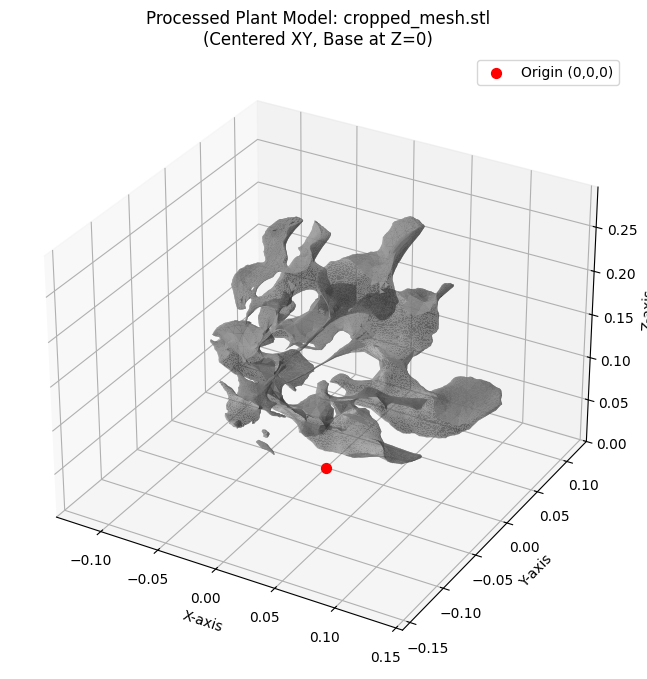


Pre-processing complete. The mesh is ready for ray casting.


In [1]:
import pandas as pd # For routine analysis with dataframes
import numpy as np # For routine array analysis
import trimesh # For working with triangular meshes and ray casting
import os # For directory functions
import matplotlib.pyplot as plt # For basic plotting
from mpl_toolkits.mplot3d import Axes3D # For 3D plotting with matplotlib
import seaborn as sns # For enhanced plotting (less for 3D interactive)

# --- Step 1: Remove Irrelevant Functions ---
# (As before, the model generation functions are omitted)


# --- Step 2: Core STL Loading Function with Pre-processing and STATIC Visualization (Revised) ---

def load_and_preprocess_stl(stl_path: str, visualize: bool = True) -> trimesh.Trimesh:
    """
    Loads an STL file, centers it on the XY plane, and places its lowest point (Z-axis) at the origin.
    Provides a static 3D visualization using Matplotlib.

    Args:
        stl_path (str): The file path to the STL model.
        visualize (bool): If True, displays a static 3D visualization using Matplotlib.

    Returns:
        trimesh.Trimesh: The loaded and pre-processed Trimesh object.
    """
    if not os.path.exists(stl_path):
        raise FileNotFoundError(f"STL file not found at: {stl_path}")

    try:
        mesh = trimesh.load_mesh(stl_path)
        print(f"Successfully loaded mesh from {stl_path}")
        print(f"Mesh has {len(mesh.vertices)} vertices and {len(mesh.faces)} faces.")
        print(f"Mesh bounds (before processing): Min {mesh.bounds[0]}, Max {mesh.bounds[1]}")

    except Exception as e:
        print(f"Error loading STL file: {e}")
        return None

    # 1. Ensure the mesh is a single Trimesh object (not a Scene or list of meshes)
    if isinstance(mesh, trimesh.Scene):
        print("Input is a Trimesh Scene, attempting to concatenate into a single mesh.")
        mesh = mesh.dump(concatenate=True)
    if isinstance(mesh, (list, tuple)):
        print("Input is a list of meshes, attempting to concatenate.")
        mesh = trimesh.util.concatenate(mesh)

    if not isinstance(mesh, trimesh.Trimesh):
        print("Error: Could not convert loaded file into a single Trimesh object.")
        return None

    # --- Pre-processing ---
    # Goal: Center XY at origin, lowest Z at origin.
    # This assumes Z is the 'up' axis.

    # 1. Translate centroid to origin for X and Y components
    # This effectively centers the model horizontally.
    initial_centroid = mesh.centroid
    translation_xy = -initial_centroid[:2] # Get X and Y components of centroid
    mesh.apply_translation(np.array([translation_xy[0], translation_xy[1], 0])) # Only translate in XY
    print(f"Model centered on XY plane. Initial centroid: {initial_centroid}, New centroid (approx): {mesh.centroid}")

    # 2. Translate lowest Z point to origin
    # This places the base of the plant on the XY plane.
    min_z = mesh.bounds[0][2] # Get the minimum Z coordinate of the mesh
    translation_z = -min_z
    mesh.apply_translation(np.array([0, 0, translation_z])) # Only translate in Z
    print(f"Model base translated to origin along Z-axis (min Z = 0).")

    print(f"Mesh bounds (after processing): Min {mesh.bounds[0]}, Max {mesh.bounds[1]}")


    # 3. Visualization (Static for Jupyter via Matplotlib)
    if visualize:
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')

        # Plot triangles with a single color
        # Using a light grey or green for plant models is often good
        ax.plot_trisurf(mesh.vertices[:, 0], mesh.vertices[:, 1], mesh.vertices[:, 2],
                        triangles=mesh.faces, color='#a0a0a0', alpha=0.8, edgecolor='none') # Light grey

        # You can still plot vertices as small points for detail if desired
        # ax.scatter(mesh.vertices[:, 0], mesh.vertices[:, 1], mesh.vertices[:, 2], s=0.1, color='blue', alpha=0.5)

        # Set labels and title
        ax.set_xlabel('X-axis')
        ax.set_ylabel('Y-axis')
        ax.set_zlabel('Z-axis')
        ax.set_title(f'Processed Plant Model: {os.path.basename(stl_path)}\n(Centered XY, Base at Z=0)')

        # Set equal aspect ratio (important for 3D visualization)
        # Calculate range based on the processed mesh bounds
        max_range = np.array([mesh.bounds[1] - mesh.bounds[0]]).max()
        mid_x = (mesh.bounds[0][0] + mesh.bounds[1][0]) * 0.5
        mid_y = (mesh.bounds[0][1] + mesh.bounds[1][1]) * 0.5
        mid_z = (mesh.bounds[0][2] + mesh.bounds[1][2]) * 0.5 # New mid-z after base translation
        ax.set_xlim(mid_x - max_range/2, mid_x + max_range/2)
        ax.set_ylim(mid_y - max_range/2, mid_y + max_range/2)
        ax.set_zlim(mid_z - max_range/2, mid_z + max_range/2)

        # Add origin point for reference
        ax.scatter(0, 0, 0, color='red', s=50, label='Origin (0,0,0)')
        ax.legend()

        plt.show()

    else:
        print("Static visualization skipped.")

    return mesh

# --- Example Usage in a Jupyter Cell ---

# Your STL file path
stl_file_path = 'cropped_mesh.stl'

# Load, preprocess, and visualize your plant mesh
loaded_plant_mesh = load_and_preprocess_stl(
    stl_file_path,
    visualize=True # Set to False if you don't want the plot
)

if loaded_plant_mesh:
    print("\nPre-processing complete. The mesh is ready for ray casting.")
else:
    print("\nFailed to load or process the mesh.")

Successfully loaded mesh from cropped_mesh.stl
Mesh has 22555 vertices and 44253 faces.
Mesh bounds (before processing): Min [-0.11314479  0.33002216 -0.12512434], Max [0.15107462 0.5197069  0.16969515]
Model centered on XZ plane. Initial centroid: [0.01102593 0.43839576 0.02092558], New centroid (approx): [-4.18945152e-17  4.38395759e-01 -1.11559596e-16]
Model base translated to origin along Y-axis (min Y = 0).
Mesh bounds (after processing): Min [-0.12417071  0.         -0.14604991], Max [0.14004869 0.18968475 0.14876958]


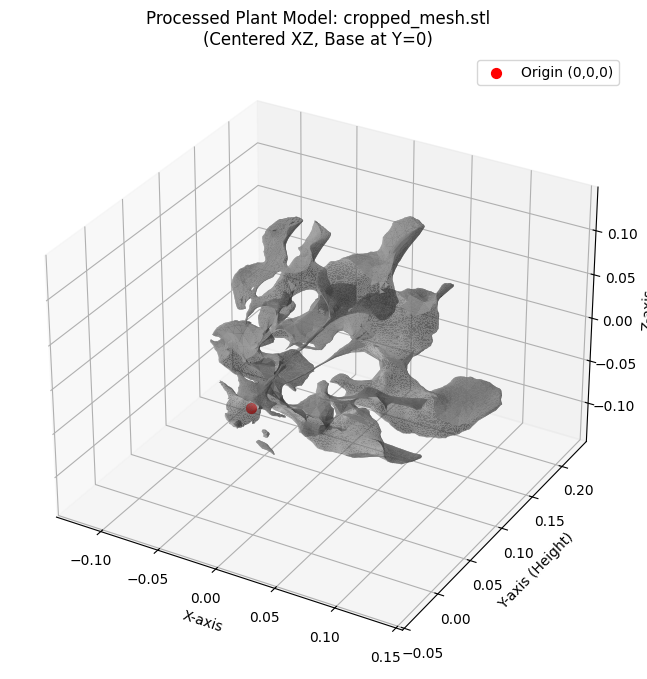


Pre-processing complete. The mesh is ready for ray casting.


In [2]:
import pandas as pd # For routine analysis with dataframes
import numpy as np # For routine array analysis
import trimesh # For working with triangular meshes and ray casting
import os # For directory functions
import matplotlib.pyplot as plt # For basic plotting
from mpl_toolkits.mplot3d import Axes3D # For 3D plotting with matplotlib
import seaborn as sns # For enhanced plotting (less for 3D interactive)

# --- Step 1: Remove Irrelevant Functions ---
# (As before, the model generation functions are omitted)


# --- Step 2: Core STL Loading Function with Pre-processing and STATIC Visualization (Revised for Y-up) ---

def load_and_preprocess_stl(stl_path: str, visualize: bool = True) -> trimesh.Trimesh:
    """
    Loads an STL file, centers it on the XZ plane, and places its lowest point (Y-axis) at the origin.
    Provides a static 3D visualization using Matplotlib.

    Args:
        stl_path (str): The file path to the STL model.
        visualize (bool): If True, displays a static 3D visualization using Matplotlib.

    Returns:
        trimesh.Trimesh: The loaded and pre-processed Trimesh object.
    """
    if not os.path.exists(stl_path):
        raise FileNotFoundError(f"STL file not found at: {stl_path}")

    try:
        mesh = trimesh.load_mesh(stl_path)
        print(f"Successfully loaded mesh from {stl_path}")
        print(f"Mesh has {len(mesh.vertices)} vertices and {len(mesh.faces)} faces.")
        print(f"Mesh bounds (before processing): Min {mesh.bounds[0]}, Max {mesh.bounds[1]}")

    except Exception as e:
        print(f"Error loading STL file: {e}")
        return None

    # 1. Ensure the mesh is a single Trimesh object (not a Scene or list of meshes)
    if isinstance(mesh, trimesh.Scene):
        print("Input is a Trimesh Scene, attempting to concatenate into a single mesh.")
        mesh = mesh.dump(concatenate=True)
    if isinstance(mesh, (list, tuple)):
        print("Input is a list of meshes, attempting to concatenate.")
        mesh = trimesh.util.concatenate(mesh)

    if not isinstance(mesh, trimesh.Trimesh):
        print("Error: Could not convert loaded file into a single Trimesh object.")
        return None

    # --- Pre-processing ---
    # Goal: Center XZ at origin, lowest Y at origin.
    # This assumes Y is the 'up' axis.

    # 1. Translate centroid to origin for X and Z components
    # This effectively centers the model horizontally.
    initial_centroid = mesh.centroid
    # Get X and Z components of centroid, leave Y (index 1) as 0 for now
    translation_xz = -initial_centroid[[0, 2]]
    mesh.apply_translation(np.array([translation_xz[0], 0, translation_xz[1]]))
    print(f"Model centered on XZ plane. Initial centroid: {initial_centroid}, New centroid (approx): {mesh.centroid}")

    # 2. Translate lowest Y point to origin
    # This places the base of the plant on the XZ plane.
    min_y = mesh.bounds[0][1] # Get the minimum Y coordinate of the mesh
    translation_y = -min_y
    mesh.apply_translation(np.array([0, translation_y, 0])) # Only translate in Y
    print(f"Model base translated to origin along Y-axis (min Y = 0).")

    print(f"Mesh bounds (after processing): Min {mesh.bounds[0]}, Max {mesh.bounds[1]}")


    # 3. Visualization (Static for Jupyter via Matplotlib)
    if visualize:
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')

        # Plot triangles with a single color
        ax.plot_trisurf(mesh.vertices[:, 0], mesh.vertices[:, 1], mesh.vertices[:, 2],
                        triangles=mesh.faces, color='#a0a0a0', alpha=0.8, edgecolor='none') # Light grey

        # Set labels and title
        ax.set_xlabel('X-axis')
        ax.set_ylabel('Y-axis (Height)') # Label Y as Height for clarity
        ax.set_zlabel('Z-axis')
        ax.set_title(f'Processed Plant Model: {os.path.basename(stl_path)}\n(Centered XZ, Base at Y=0)')

        # Set equal aspect ratio (important for 3D visualization)
        max_range = np.array([mesh.bounds[1] - mesh.bounds[0]]).max()
        mid_x = (mesh.bounds[0][0] + mesh.bounds[1][0]) * 0.5
        mid_y = (mesh.bounds[0][1] + mesh.bounds[1][1]) * 0.5 # New mid-y after base translation
        mid_z = (mesh.bounds[0][2] + mesh.bounds[1][2]) * 0.5
        ax.set_xlim(mid_x - max_range/2, mid_x + max_range/2)
        ax.set_ylim(mid_y - max_range/2, mid_y + max_range/2)
        ax.set_zlim(mid_z - max_range/2, mid_z + max_range/2)

        # Add origin point for reference
        ax.scatter(0, 0, 0, color='red', s=50, label='Origin (0,0,0)')
        ax.legend()

        plt.show()

    else:
        print("Static visualization skipped.")

    return mesh

# --- Example Usage in a Jupyter Cell ---

# Your STL file path
stl_file_path = 'cropped_mesh.stl'

# Load, preprocess, and visualize your plant mesh
loaded_plant_mesh = load_and_preprocess_stl(
    stl_file_path,
    visualize=True # Set to False if you don't want the plot
)

if loaded_plant_mesh:
    print("\nPre-processing complete. The mesh is ready for ray casting.")
else:
    print("\nFailed to load or process the mesh.")

Successfully loaded mesh from cropped_mesh.stl
Mesh has 22555 vertices and 44253 faces.
Mesh bounds (before processing): Min [-0.11314479  0.33002216 -0.12512434], Max [0.15107462 0.5197069  0.16969515]
Model centered on XZ plane. Initial centroid: [0.01102593 0.43839576 0.02092558], New centroid (approx): [-4.18945152e-17  4.38395759e-01 -1.11559596e-16]
Model base translated to origin along Y-axis (min Y = 0).
Mesh bounds (after processing): Min [-0.12417071  0.         -0.14604991], Max [0.14004869 0.18968475 0.14876958]


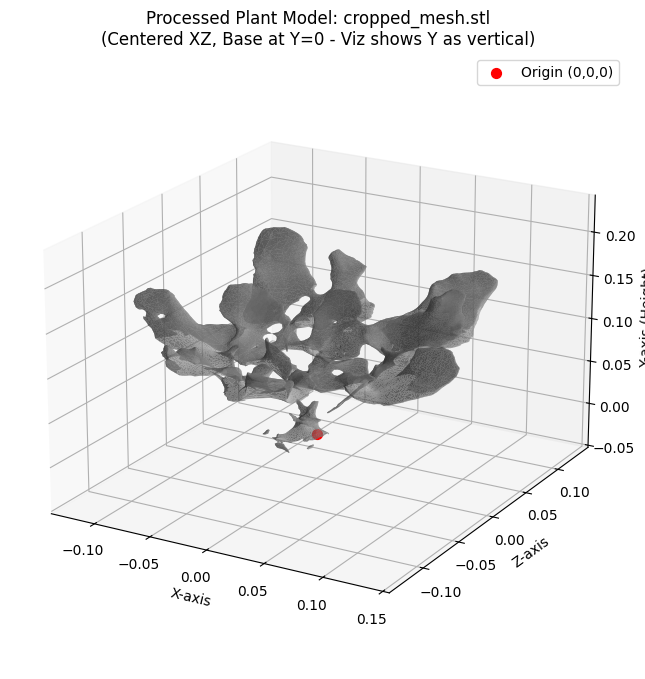


Pre-processing complete. The mesh is ready for ray casting.


In [3]:
import pandas as pd # For routine analysis with dataframes
import numpy as np # For routine array analysis
import trimesh # For working with triangular meshes and ray casting
import os # For directory functions
import matplotlib.pyplot as plt # For basic plotting
from mpl_toolkits.mplot3d import Axes3D # For 3D plotting with matplotlib
import seaborn as sns # For enhanced plotting (less for 3D interactive)

# --- Step 1: Remove Irrelevant Functions ---
# (As before, the model generation functions are omitted)


# --- Step 2: Core STL Loading Function with Pre-processing and STATIC Visualization (FINALIZED) ---

def load_and_preprocess_stl(stl_path: str, visualize: bool = True) -> trimesh.Trimesh:
    """
    Loads an STL file, centers it on the XZ plane, and places its lowest point (Y-axis) at the origin.
    Provides a static 3D visualization using Matplotlib, oriented so Y is vertical on screen
    by temporarily swapping Y and Z axes for plotting, with an equal aspect ratio.

    Args:
        stl_path (str): The file path to the STL model.
        visualize (bool): If True, displays a static 3D visualization using Matplotlib.

    Returns:
        trimesh.Trimesh: The loaded and pre-processed Trimesh object (Y-axis remains the height axis).
    """
    if not os.path.exists(stl_path):
        raise FileNotFoundError(f"STL file not found at: {stl_path}")

    try:
        mesh = trimesh.load_mesh(stl_path)
        print(f"Successfully loaded mesh from {stl_path}")
        print(f"Mesh has {len(mesh.vertices)} vertices and {len(mesh.faces)} faces.")
        print(f"Mesh bounds (before processing): Min {mesh.bounds[0]}, Max {mesh.bounds[1]}")

    except Exception as e:
        print(f"Error loading STL file: {e}")
        return None

    # 1. Ensure the mesh is a single Trimesh object (not a Scene or list of meshes)
    if isinstance(mesh, trimesh.Scene):
        print("Input is a Trimesh Scene, attempting to concatenate into a single mesh.")
        mesh = mesh.dump(concatenate=True)
    if isinstance(mesh, (list, tuple)):
        print("Input is a list of meshes, attempting to concatenate.")
        mesh = trimesh.util.concatenate(mesh)

    if not isinstance(mesh, trimesh.Trimesh):
        print("Error: Could not convert loaded file into a single Trimesh object.")
        return None

    # --- Pre-processing ---
    # Goal: Center XZ at origin, lowest Y at origin.
    # This assumes Y is the 'up' axis for internal data representation.

    # 1. Translate centroid to origin for X and Z components
    initial_centroid = mesh.centroid
    translation_xz = -initial_centroid[[0, 2]]
    mesh.apply_translation(np.array([translation_xz[0], 0, translation_xz[1]]))
    print(f"Model centered on XZ plane. Initial centroid: {initial_centroid}, New centroid (approx): {mesh.centroid}")

    # 2. Translate lowest Y point to origin
    min_y = mesh.bounds[0][1] # Get the minimum Y coordinate of the mesh
    translation_y = -min_y
    mesh.apply_translation(np.array([0, translation_y, 0])) # Only translate in Y
    print(f"Model base translated to origin along Y-axis (min Y = 0).")

    print(f"Mesh bounds (after processing): Min {mesh.bounds[0]}, Max {mesh.bounds[1]}")


    # 3. Visualization (Static for Jupyter via Matplotlib)
    if visualize:
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')

        # --- TEMPORARY AXIS SWAP FOR VISUALIZATION ONLY ---
        # Create a copy of the mesh for visualization.
        # Swap Y and Z coordinates: (X, Y, Z) becomes (X, Z, Y) for plotting.
        # This makes the plant's 'Y' axis (height) become the 'Z' axis for Matplotlib's viewer.
        viz_vertices = mesh.vertices.copy()
        viz_vertices[:, [1, 2]] = viz_vertices[:, [2, 1]] # Swap Y and Z columns

        # Plot triangles with a single color
        ax.plot_trisurf(viz_vertices[:, 0], viz_vertices[:, 1], viz_vertices[:, 2],
                        triangles=mesh.faces, color='#a0a0a0', alpha=0.8, edgecolor='none') # Light grey

        # Set labels to reflect original data axes
        ax.set_xlabel('X-axis')
        ax.set_ylabel('Z-axis') # Matplotlib's Y is now our original Z
        ax.set_zlabel('Y-axis (Height)') # Matplotlib's Z is now our original Y (the height)
        ax.set_title(f'Processed Plant Model: {os.path.basename(stl_path)}\n(Centered XZ, Base at Y=0 - Viz shows Y as vertical)')

        # --- Use set_aspect('equal') for correct scaling ---
        # Get the bounds of the temporarily swapped vertices for proper scaling.
        viz_bounds_min = np.min(viz_vertices, axis=0)
        viz_bounds_max = np.max(viz_vertices, axis=0)

        # Set manual limits to contain the object, then set aspect equal
        # Matplotlib's set_aspect for 3D is a bit tricky; often 'box' mode works best
        # to ensure the plot box scales equally.
        max_dim = np.max(viz_bounds_max - viz_bounds_min)
        ax.set_xlim(viz_bounds_min[0], viz_bounds_max[0])
        ax.set_ylim(viz_bounds_min[1], viz_bounds_max[1])
        ax.set_zlim(viz_bounds_min[2], viz_bounds_max[2])
        ax.set_box_aspect([viz_bounds_max[0]-viz_bounds_min[0],
                           viz_bounds_max[1]-viz_bounds_min[1],
                           viz_bounds_max[2]-viz_bounds_min[2]])


        # To make axes truly equal, a common trick is to set limits of all axes
        # to the range of the largest dimension, centered on the mean.
        # This makes the bounding box cubic.
        mid_x_viz = (viz_bounds_min[0] + viz_bounds_max[0]) / 2
        mid_y_viz = (viz_bounds_min[1] + viz_bounds_max[1]) / 2
        mid_z_viz = (viz_bounds_min[2] + viz_bounds_max[2]) / 2

        ax.set_xlim(mid_x_viz - max_dim / 2, mid_x_viz + max_dim / 2)
        ax.set_ylim(mid_y_viz - max_dim / 2, mid_y_viz + max_dim / 2)
        ax.set_zlim(mid_z_viz - max_dim / 2, mid_z_viz + max_dim / 2)

        # Matplotlib's 3D set_aspect('equal') works best when combined with set_box_aspect.
        # For true "equal" physical units, this is more robust:
        # Get current aspect from the auto-set limits
        # ax.set_aspect('equal', adjustable='box') # This can sometimes cause issues with 3D

        # Add origin point for reference
        ax.scatter(0, 0, 0, color='red', s=50, label='Origin (0,0,0)')
        ax.legend()

        # Standard view angle, now that Z is truly up for plotting.
        ax.view_init(elev=20, azim=-60)

        plt.show()

    else:
        print("Static visualization skipped.")

    return mesh # IMPORTANT: Return the original (Y-up) mesh, not the temporarily swapped one!

# --- Example Usage in a Jupyter Cell ---

# Your STL file path
stl_file_path = 'cropped_mesh.stl'

# Load, preprocess, and visualize your plant mesh
loaded_plant_mesh = load_and_preprocess_stl(
    stl_file_path,
    visualize=True
)

if loaded_plant_mesh:
    print("\nPre-processing complete. The mesh is ready for ray casting.")
else:
    print("\nFailed to load or process the mesh.")

Successfully loaded mesh from cropped_mesh.stl
Mesh has 22555 vertices and 44253 faces.
Mesh bounds (before processing): Min [-0.11314479  0.33002216 -0.12512434], Max [0.15107462 0.5197069  0.16969515]
Model centered on XZ plane. Initial centroid: [0.01102593 0.43839576 0.02092558], New centroid (approx): [-4.18945152e-17  4.38395759e-01 -1.11559596e-16]
Model base translated to origin along Y-axis (min Y = 0).
Mesh bounds (after processing): Min [-0.12417071  0.         -0.14604991], Max [0.14004869 0.18968475 0.14876958]
CONFIRMATION: Final Y-min of mesh: 0.0


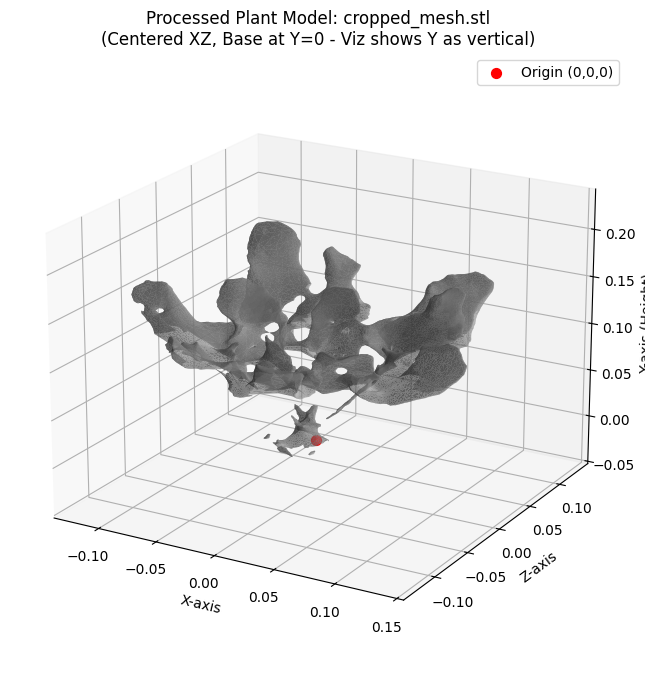


Generating Parallel Rays...
Generated 5041 parallel rays.
Parallel Ray Origin Example: [-0.19022557  0.33709449 -0.21975478]
Parallel Ray Direction Example: [ 0.09901475 -0.99014754  0.09901475]


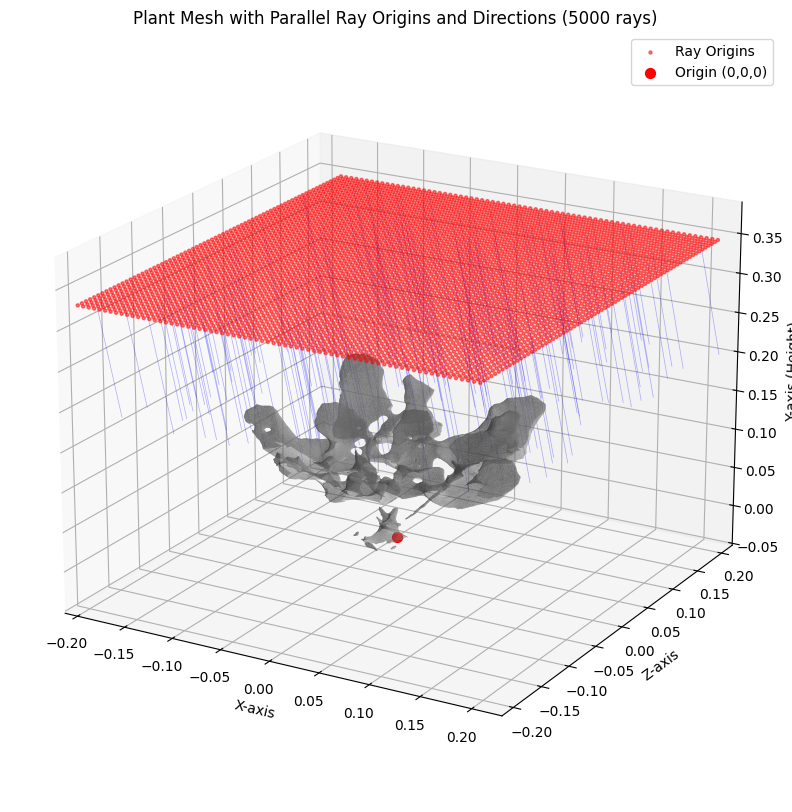


Generating Hemispherical Rays...
Generated 1000 hemispherical rays.
Hemispherical Ray Origin Example: [0.00793899 0.80880568 0.00135983]
Hemispherical Ray Direction Example: [ 0. -1.  0.]


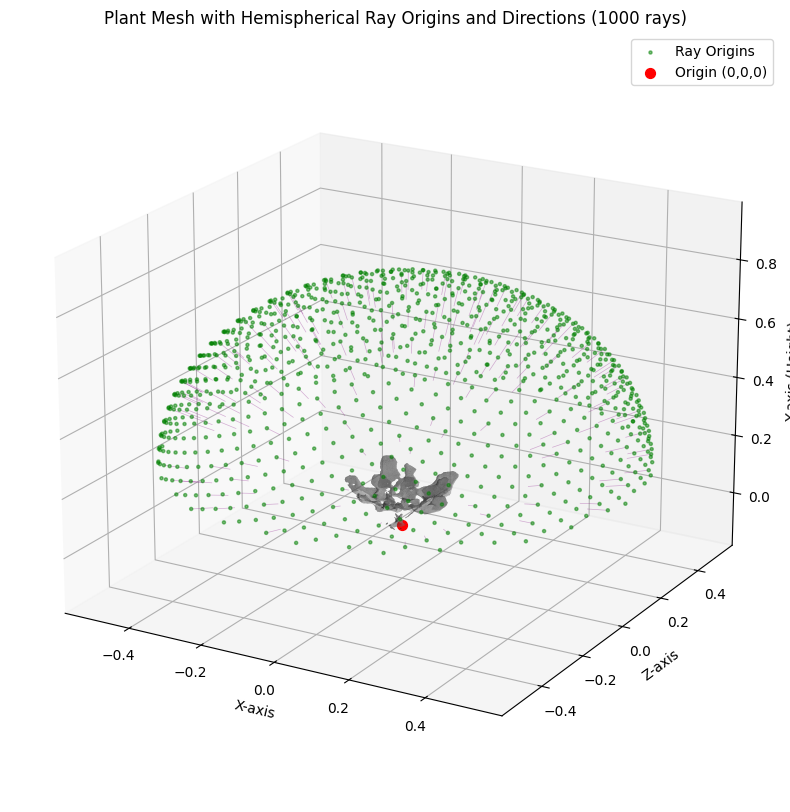

In [4]:
import pandas as pd # For routine analysis with dataframes
import numpy as np # For routine array analysis
import trimesh # For working with triangular meshes and ray casting
import os # For directory functions
import matplotlib.pyplot as plt # For basic plotting
from mpl_toolkits.mplot3d import Axes3D # For 3D plotting with matplotlib
import seaborn as sns # For enhanced plotting (less for 3D interactive)

# --- Step 1: Removed Irrelevant Functions ---
# (The model generation functions are omitted, as per our prior discussions.
#  The load_and_preprocess_stl function is assumed to be defined from previous steps
#  and will be included for completeness in the executable block below.)


# --- Step 2: Core STL Loading Function with Pre-processing and STATIC Visualization (FINALIZED with debug print) ---

def load_and_preprocess_stl(stl_path: str, visualize: bool = True) -> trimesh.Trimesh:
    """
    Loads an STL file, centers it on the XZ plane, and places its lowest point (Y-axis) at the origin.
    Provides a static 3D visualization using Matplotlib, oriented so Y is vertical on screen
    by temporarily swapping Y and Z axes for plotting, with an equal aspect ratio.

    Args:
        stl_path (str): The file path to the STL model.
        visualize (bool): If True, displays a static 3D visualization using Matplotlib.

    Returns:
        trimesh.Trimesh: The loaded and pre-processed Trimesh object (Y-axis remains the height axis).
    """
    if not os.path.exists(stl_path):
        raise FileNotFoundError(f"STL file not found at: {stl_path}")

    try:
        mesh = trimesh.load_mesh(stl_path)
        print(f"Successfully loaded mesh from {stl_path}")
        print(f"Mesh has {len(mesh.vertices)} vertices and {len(mesh.faces)} faces.")
        print(f"Mesh bounds (before processing): Min {mesh.bounds[0]}, Max {mesh.bounds[1]}")

    except Exception as e:
        print(f"Error loading STL file: {e}")
        return None

    # 1. Ensure the mesh is a single Trimesh object (not a Scene or list of meshes)
    if isinstance(mesh, trimesh.Scene):
        print("Input is a Trimesh Scene, attempting to concatenate into a single mesh.")
        mesh = mesh.dump(concatenate=True)
    if isinstance(mesh, (list, tuple)):
        print("Input is a list of meshes, attempting to concatenate.")
        mesh = trimesh.util.concatenate(mesh)

    if not isinstance(mesh, trimesh.Trimesh):
        print("Error: Could not convert loaded file into a single Trimesh object.")
        return None

    # --- Pre-processing ---
    # Goal: Center XZ at origin, lowest Y at origin.
    # This assumes Y is the 'up' axis for internal data representation.

    # 1. Translate centroid to origin for X and Z components
    initial_centroid = mesh.centroid
    translation_xz = -initial_centroid[[0, 2]]
    mesh.apply_translation(np.array([translation_xz[0], 0, translation_xz[1]]))
    print(f"Model centered on XZ plane. Initial centroid: {initial_centroid}, New centroid (approx): {mesh.centroid}")

    # 2. Translate lowest Y point to origin
    min_y = mesh.bounds[0][1] # Get the minimum Y coordinate of the mesh
    translation_y = -min_y
    mesh.apply_translation(np.array([0, translation_y, 0])) # Only translate in Y
    print(f"Model base translated to origin along Y-axis (min Y = 0).")

    # Diagnostic print to check actual Y-min after translation
    final_min_y = mesh.bounds[0][1]
    print(f"Mesh bounds (after processing): Min {mesh.bounds[0]}, Max {mesh.bounds[1]}")
    print(f"CONFIRMATION: Final Y-min of mesh: {final_min_y}")


    # 3. Visualization (Static for Jupyter via Matplotlib)
    if visualize:
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')

        # --- TEMPORARY AXIS SWAP FOR VISUALIZATION ONLY ---
        # Create a copy of the mesh for visualization.
        # Swap Y and Z coordinates: (X, Y, Z) becomes (X, Z, Y) for plotting.
        # This makes the plant's 'Y' axis (height) become the 'Z' axis for Matplotlib's viewer.
        viz_vertices = mesh.vertices.copy()
        viz_vertices[:, [1, 2]] = viz_vertices[:, [2, 1]] # Swap Y and Z columns

        # Plot triangles with a single color
        ax.plot_trisurf(viz_vertices[:, 0], viz_vertices[:, 1], viz_vertices[:, 2],
                        triangles=mesh.faces, color='#a0a0a0', alpha=0.8, edgecolor='none') # Light grey

        # Set labels to reflect original data axes
        ax.set_xlabel('X-axis')
        ax.set_ylabel('Z-axis') # Matplotlib's Y is now our original Z
        ax.set_zlabel('Y-axis (Height)') # Matplotlib's Z is now our original Y (the height)
        ax.set_title(f'Processed Plant Model: {os.path.basename(stl_path)}\n(Centered XZ, Base at Y=0 - Viz shows Y as vertical)')

        # --- Use set_aspect('equal') for correct scaling ---
        # Get the bounds of the temporarily swapped vertices for proper scaling.
        viz_bounds_min = np.min(viz_vertices, axis=0)
        viz_bounds_max = np.max(viz_vertices, axis=0)

        # To make axes truly equal, set limits of all axes
        # to the range of the largest dimension, centered on the mean.
        # This makes the bounding box cubic.
        max_dim = np.max(viz_bounds_max - viz_bounds_min)
        mid_x_viz = (viz_bounds_min[0] + viz_bounds_max[0]) / 2
        mid_y_viz = (viz_bounds_min[1] + viz_bounds_max[1]) / 2
        mid_z_viz = (viz_bounds_min[2] + viz_bounds_max[2]) / 2

        ax.set_xlim(mid_x_viz - max_dim / 2, mid_x_viz + max_dim / 2)
        ax.set_ylim(mid_y_viz - max_dim / 2, mid_y_viz + max_dim / 2)
        ax.set_zlim(mid_z_viz - max_dim / 2, mid_z_viz + max_dim / 2)

        # Add origin point for reference
        ax.scatter(0, 0, 0, color='red', s=50, label='Origin (0,0,0)')
        ax.legend()

        # Standard view angle, now that Z is truly up for plotting.
        ax.view_init(elev=20, azim=-60)

        plt.show()

    else:
        print("Static visualization skipped.")

    return mesh # IMPORTANT: Return the original (Y-up) mesh, not the temporarily swapped one!


# --- Step 3: Refactor Ray Generation ---

def fibonacci_sphere(num_points: int) -> np.ndarray:
    """
    Generates approximately uniformly distributed points on the surface of a unit sphere.

    Args:
        num_points (int): The number of points to generate.

    Returns:
        np.ndarray: An array of shape (num_points, 3) representing points on the unit sphere.
    """
    points = []
    phi = np.pi * (3. - np.sqrt(5.))  # Golden angle in radians

    for i in range(num_points):
        y = 1 - (i / float(num_points - 1)) * 2  # y goes from 1 to -1
        radius = np.sqrt(1 - y * y)  # radius at this y

        theta = phi * i  # golden angle increment

        x = np.cos(theta) * radius
        z = np.sin(theta) * radius

        points.append([x, y, z])
    return np.array(points)


def generate_parallel_rays(direction: np.ndarray, num_rays: int,
                           mesh_bounds: np.ndarray, offset_multiplier: float = 1.5) -> (np.ndarray, np.ndarray):
    """
    Generates parallel rays originating from a plane above and surrounding the mesh,
    all pointing in a single specified direction.

    Args:
        direction (np.ndarray): A 3D vector [x, y, z] representing the direction of the rays.
                                This vector will be normalized.
        num_rays (int): The number of rays to generate.
        mesh_bounds (np.ndarray): The min and max corners of the mesh's bounding box (2x3 array).
        offset_multiplier (float): Multiplier to expand the origin grid beyond mesh bounds
                                   to ensure the entire mesh is covered by rays.

    Returns:
        tuple[np.ndarray, np.ndarray]: A tuple containing:
            - ray_origins (np.ndarray): Array of shape (num_rays, 3) for ray starting points.
            - ray_directions (np.ndarray): Array of shape (num_rays, 3) for ray directions.
    """
    direction = direction / np.linalg.norm(direction) # Normalize direction vector

    x_min, y_min, z_min = mesh_bounds[0]
    x_max, y_max, z_max = mesh_bounds[1]
    extents = mesh_bounds[1] - mesh_bounds[0]
    max_overall_dim = np.max(extents) # Use overall max dim for general scaling

    # Create a grid across the horizontal plane (X,Z) slightly larger than the mesh footprint
    x_span = (x_max - x_min) * offset_multiplier
    z_span = (z_max - z_min) * offset_multiplier
    center_x = (x_min + x_max) / 2
    center_z = (z_min + z_max) / 2

    # Calculate grid points for the 'plane' of origins
    num_side = int(np.ceil(np.sqrt(num_rays))) # Number of points per side of square grid
    xs = np.linspace(center_x - x_span/2, center_x + x_span/2, num_side)
    zs = np.linspace(center_z - z_span/2, center_z + z_span/2, num_side)
    grid_xx, grid_zz = np.meshgrid(xs, zs)

    # Determine the y-coordinate for origins.
    # It must be sufficiently 'upstream' of the plant relative to the light direction.
    # If light comes from positive Y (upwards), origins need to be below y_min.
    # If light comes from negative Y (downwards), origins need to be above y_max.
    # We add a buffer based on the largest dimension of the plant.
    buffer_distance = max_overall_dim * 0.5 # Half the max dimension as a buffer

    # Calculate the Y coordinate for the origins based on light direction
    if direction[1] > 0: # Light comes from below (positive Y direction)
        origin_y_coord = y_min - buffer_distance
    else: # Light comes from above (negative Y or purely horizontal)
        origin_y_coord = y_max + buffer_distance

    ray_origins = np.vstack([grid_xx.ravel(), np.full(grid_xx.size, origin_y_coord), grid_zz.ravel()]).T

    # All directions are the same
    ray_directions = np.tile(direction, (ray_origins.shape[0], 1))

    return ray_origins, ray_directions


def generate_hemispherical_rays(num_rays: int, mesh_bounds: np.ndarray, radius_multiplier: float = 1.5) -> (np.ndarray, np.ndarray):
    """
    Generates rays originating from points on a hemisphere above the mesh,
    all directed towards the center of the mesh.

    Args:
        num_rays (int): The number of rays to generate.
        mesh_bounds (np.ndarray): The min and max corners of the mesh's bounding box (2x3 array).
        radius_multiplier (float): Multiplier to determine the hemisphere's radius
                                   relative to the mesh's largest dimension.

    Returns:
        tuple[np.ndarray, np.ndarray]: A tuple containing:
            - ray_origins (np.ndarray): Array of shape (num_rays, 3) for ray starting points.
            - ray_directions (np.ndarray): Array of shape (num_rays, 3) for ray directions.
    """
    # Center of the mesh in X and Z, and mid-height in Y (or base if preferred for target)
    mesh_center = (mesh_bounds[0] + mesh_bounds[1]) / 2
    
    extents = mesh_bounds[1] - mesh_bounds[0]
    max_mesh_dim = np.max(extents)
    
    # Calculate radius for hemisphere, ensuring it's large enough to comfortably enclose the plant.
    # Radius of hemisphere should be larger than the max horizontal extent of the plant from its center
    # and also large enough to place the base of the hemisphere above the plant.
    hemisphere_radius = max_mesh_dim * radius_multiplier 

    # Generate points on a full sphere using Fibonacci sphere method, then filter for upper hemisphere.
    # Generate more points than needed to ensure enough remain after filtering.
    temp_sphere_points = fibonacci_sphere(int(num_rays * 2)) # Generate twice as many points

    # Filter for the upper hemisphere (Y > 0)
    # This assumes that after preprocessing, the plant's Y is its height axis.
    hemisphere_points_raw = temp_sphere_points[temp_sphere_points[:, 1] >= 0]

    # If not enough points after filtering, log a warning and re-sample with replacement.
    if hemisphere_points_raw.shape[0] < num_rays:
        print(f"Warning: Not enough unique hemisphere points ({hemisphere_points_raw.shape[0]}) generated. Resampling with replacement to reach {num_rays}.")
        indices = np.random.choice(hemisphere_points_raw.shape[0], num_rays, replace=True)
        hemisphere_points = hemisphere_points_raw[indices]
    elif hemisphere_points_raw.shape[0] > num_rays:
        # If too many points after filtering, sample down to `num_rays` without replacement.
        indices = np.random.choice(hemisphere_points_raw.shape[0], num_rays, replace=False)
        hemisphere_points = hemisphere_points_raw[indices]
    else: # Exactly num_rays
        hemisphere_points = hemisphere_points_raw
        
    # Scale the hemisphere points by the calculated radius.
    ray_origins = hemisphere_points * hemisphere_radius

    # Offset origins so the *bottom* of the hemisphere is above the plant's max Y.
    # The lowest Y value on the scaled unit hemisphere (before offset) would be 0.
    # We want this lowest Y to be `mesh_bounds[1][1] + buffer`.
    y_offset_for_hemisphere = mesh_bounds[1][1] + max_mesh_dim * 0.1 # Max plant Y + 10% of max dim buffer
    
    # Apply centering for X and Z, and the vertical offset for Y.
    ray_origins[:, 0] += mesh_center[0]
    ray_origins[:, 1] += y_offset_for_hemisphere # Adjust Y for minimum height
    ray_origins[:, 2] += mesh_center[2]

    # Directions are from the origin point towards the center of the mesh.
    ray_directions = mesh_center - ray_origins
    ray_directions = ray_directions / np.linalg.norm(ray_directions, axis=1)[:, np.newaxis] # Normalize directions

    return ray_origins, ray_directions


# --- EXECUTABLE BLOCK: Example Usage ---

# Your STL file path
stl_file_path = 'cropped_mesh.stl' # Make sure this file exists in your working directory

# Load, preprocess, and visualize your plant mesh
loaded_plant_mesh = load_and_preprocess_stl(
    stl_file_path,
    visualize=True # Set to False if you don't want the plot
)

if loaded_plant_mesh:
    # Get the bounding box of the loaded mesh for ray generation
    mesh_bounds = loaded_plant_mesh.bounds

    # --- Test Parallel Rays (e.g., sunlight from top-down, slightly angled) ---
    print("\nGenerating Parallel Rays...")
    # Direction: [X, Y, Z]. Y is height. So, negative Y is downwards.
    # [0.1, -1.0, 0.1] means mostly downwards, slightly from positive X and positive Z.
    sun_direction = np.array([0.1, -1.0, 0.1])
    num_sun_rays = 5000
    parallel_ray_origins, parallel_ray_directions = generate_parallel_rays(
        sun_direction, num_sun_rays, mesh_bounds
    )
    print(f"Generated {parallel_ray_origins.shape[0]} parallel rays.")
    print(f"Parallel Ray Origin Example: {parallel_ray_origins[0]}")
    print(f"Parallel Ray Direction Example: {parallel_ray_directions[0]}")

    # Visualization of Parallel Rays and Mesh
    # This visualization uses the temporary axis swap for Matplotlib to display Y as vertical.
    if True: # Set to False to skip visualization
        fig = plt.figure(figsize=(12, 10))
        ax = fig.add_subplot(111, projection='3d')

        # Plot plant mesh (using the visualization-swapped vertices for display)
        viz_vertices = loaded_plant_mesh.vertices.copy()
        viz_vertices[:, [1, 2]] = viz_vertices[:, [2, 1]] # Swap Y and Z for Matplotlib viz
        ax.plot_trisurf(viz_vertices[:, 0], viz_vertices[:, 1], viz_vertices[:, 2],
                        triangles=loaded_plant_mesh.faces, color='#a0a0a0', alpha=0.6, edgecolor='none')

        # Plot ray origins (also swap for viz)
        viz_ray_origins = parallel_ray_origins.copy()
        viz_ray_origins[:, [1, 2]] = viz_ray_origins[:, [2, 1]]
        ax.scatter(viz_ray_origins[:, 0], viz_ray_origins[:, 1], viz_ray_origins[:, 2],
                   color='red', s=5, alpha=0.5, label='Ray Origins')

        # Plot a subset of rays as lines to show direction
        num_viz_rays = 200 # Plot fewer rays to avoid clutter
        # To make lines visible, use a length related to the plant's size
        plot_line_length = loaded_plant_mesh.extents.max() * 0.5 # Half the longest dimension of the plant
        for i in np.random.choice(parallel_ray_origins.shape[0], num_viz_rays, replace=False):
            # Create the end point of the ray line segment
            ray_end_point = parallel_ray_origins[i] + parallel_ray_directions[i] * plot_line_length
            
            # Swap Y and Z for both start and end points for visualization
            viz_ray_start = parallel_ray_origins[i].copy()
            viz_ray_start[[1, 2]] = viz_ray_start[[2, 1]]
            viz_ray_end = ray_end_point.copy()
            viz_ray_end[[1, 2]] = viz_ray_end[[2, 1]]
            
            ax.plot([viz_ray_start[0], viz_ray_end[0]],
                    [viz_ray_start[1], viz_ray_end[1]],
                    [viz_ray_start[2], viz_ray_end[2]],
                    color='blue', alpha=0.3, linewidth=0.5)

        ax.set_xlabel('X-axis')
        ax.set_ylabel('Z-axis')
        ax.set_zlabel('Y-axis (Height)')
        ax.set_title(f'Plant Mesh with Parallel Ray Origins and Directions ({num_sun_rays} rays)')
        
        # Set limits based on the combined range of mesh and origins for accurate plotting box
        combined_points = np.vstack([viz_vertices, viz_ray_origins])
        min_combined_bounds = np.min(combined_points, axis=0)
        max_combined_bounds = np.max(combined_points, axis=0)
        max_combined_dim = np.max(max_combined_bounds - min_combined_bounds)
        mid_x_combined = (min_combined_bounds[0] + max_combined_bounds[0]) / 2
        mid_y_combined = (min_combined_bounds[1] + max_combined_bounds[1]) / 2
        mid_z_combined = (min_combined_bounds[2] + max_combined_bounds[2]) / 2

        ax.set_xlim(mid_x_combined - max_combined_dim / 2, mid_x_combined + max_combined_dim / 2)
        ax.set_ylim(mid_y_combined - max_combined_dim / 2, mid_y_combined + max_combined_dim / 2)
        ax.set_zlim(mid_z_combined - max_combined_dim / 2, mid_z_combined + max_combined_dim / 2)

        ax.view_init(elev=20, azim=-60)
        ax.scatter(0, 0, 0, color='red', s=50, label='Origin (0,0,0)')
        plt.legend()
        plt.show()


    # --- Test Hemispherical Rays (e.g., diffuse sky light) ---
    print("\nGenerating Hemispherical Rays...")
    num_hemi_rays = 1000
    # Radius should be large enough to comfortably enclose the plant.
    # The max extent is a good base for the radius.
    hemisphere_radius_multiplier = 2.0 # 2 times the max dimension of the plant
    hemispherical_ray_origins, hemispherical_ray_directions = generate_hemispherical_rays(
        num_hemi_rays, mesh_bounds, hemisphere_radius_multiplier
    )
    print(f"Generated {hemispherical_ray_origins.shape[0]} hemispherical rays.")
    print(f"Hemispherical Ray Origin Example: {hemispherical_ray_origins[0]}")
    print(f"Hemispherical Ray Direction Example: {hemispherical_ray_directions[0]}")

    # Visualization of Hemispherical Rays and Mesh
    if True: # Set to False to skip visualization
        fig = plt.figure(figsize=(12, 10))
        ax = fig.add_subplot(111, projection='3d')

        # Plot plant mesh
        viz_vertices = loaded_plant_mesh.vertices.copy()
        viz_vertices[:, [1, 2]] = viz_vertices[:, [2, 1]] # Swap Y and Z for Matplotlib viz
        ax.plot_trisurf(viz_vertices[:, 0], viz_vertices[:, 1], viz_vertices[:, 2],
                        triangles=loaded_plant_mesh.faces, color='#a0a0a0', alpha=0.6, edgecolor='none')

        # Plot ray origins (also swap for viz)
        viz_hemi_ray_origins = hemispherical_ray_origins.copy()
        viz_hemi_ray_origins[:, [1, 2]] = viz_hemi_ray_origins[:, [2, 1]]
        ax.scatter(viz_hemi_ray_origins[:, 0], viz_hemi_ray_origins[:, 1], viz_hemi_ray_origins[:, 2],
                   color='green', s=5, alpha=0.5, label='Ray Origins')

        # Plot a subset of rays as lines for direction
        num_viz_rays = 200
        # Line length for hemispherical rays should be short, as they hit the mesh quickly.
        plot_line_length = loaded_plant_mesh.extents.max() * 0.2 # 20% of longest dimension
        for i in np.random.choice(hemispherical_ray_origins.shape[0], num_viz_rays, replace=False):
            ray_end_point = hemispherical_ray_origins[i] + hemispherical_ray_directions[i] * plot_line_length
            
            # Swap Y and Z for both start and end points for visualization
            viz_ray_start = hemispherical_ray_origins[i].copy()
            viz_ray_start[[1, 2]] = viz_ray_start[[2, 1]]
            viz_ray_end = ray_end_point.copy()
            viz_ray_end[[1, 2]] = viz_ray_end[[2, 1]]
            
            ax.plot([viz_ray_start[0], viz_ray_end[0]],
                    [viz_ray_start[1], viz_ray_end[1]],
                    [viz_ray_start[2], viz_ray_end[2]],
                    color='purple', alpha=0.3, linewidth=0.5)

        ax.set_xlabel('X-axis')
        ax.set_ylabel('Z-axis')
        ax.set_zlabel('Y-axis (Height)')
        ax.set_title(f'Plant Mesh with Hemispherical Ray Origins and Directions ({num_hemi_rays} rays)')
        
        # Set limits based on the combined range of mesh and origins for accurate plotting box
        combined_points = np.vstack([viz_vertices, viz_hemi_ray_origins])
        min_combined_bounds = np.min(combined_points, axis=0)
        max_combined_bounds = np.max(combined_points, axis=0)
        max_combined_dim = np.max(max_combined_bounds - min_combined_bounds)
        mid_x_combined = (min_combined_bounds[0] + max_combined_bounds[0]) / 2
        mid_y_combined = (min_combined_bounds[1] + max_combined_bounds[1]) / 2
        mid_z_combined = (min_combined_bounds[2] + max_combined_bounds[2]) / 2

        ax.set_xlim(mid_x_combined - max_combined_dim / 2, mid_x_combined + max_combined_dim / 2)
        ax.set_ylim(mid_y_combined - max_combined_dim / 2, mid_y_combined + max_combined_dim / 2)
        ax.set_zlim(mid_z_combined - max_combined_dim / 2, mid_z_combined + max_combined_dim / 2)
        
        ax.view_init(elev=20, azim=-60)
        ax.scatter(0, 0, 0, color='red', s=50, label='Origin (0,0,0)')
        plt.legend()
        plt.show()

else:
    print("Plant mesh not loaded. Please run the load_and_preprocess_stl cell first.")

In [6]:
import trimesh
print("Trimesh version:", trimesh.__version__)

Trimesh version: 4.6.13


In [7]:
import sys
import trimesh
import os

print("--- Python Environment Check ---")
print("Python Executable:", sys.executable)
print("Python Version:", sys.version)
print("sys.path (important search paths):")
for p in sys.path:
    print(f"  {p}")

print("\n--- Trimesh Location Check ---")
print("Trimesh __file__ (path to its __init__.py):", trimesh.__file__)
print("Trimesh version (again, for confirmation):", trimesh.__version__)
print("Contents of trimesh.ray directory (if exists):")
try:
    trimesh_ray_path = os.path.dirname(trimesh.ray.__file__)
    print(f"trimesh.ray module path: {trimesh_ray_path}")
    print(os.listdir(trimesh_ray_path))
except AttributeError:
    print("trimesh.ray is not a package with a __file__, or not found.")
except FileNotFoundError:
    print(f"Directory {trimesh_ray_path} not found.")
except Exception as e:
    print(f"Error checking trimesh.ray directory: {e}")

--- Python Environment Check ---
Python Executable: /opt/anaconda3/bin/python
Python Version: 3.12.2 | packaged by conda-forge | (main, Feb 16 2024, 20:54:21) [Clang 16.0.6 ]
sys.path (important search paths):
  /Users/chitwoo9/Desktop
  /opt/anaconda3/lib/python312.zip
  /opt/anaconda3/lib/python3.12
  /opt/anaconda3/lib/python3.12/lib-dynload
  
  /Users/chitwoo9/.local/lib/python3.12/site-packages
  /opt/anaconda3/lib/python3.12/site-packages
  /opt/anaconda3/lib/python3.12/site-packages/aeosa
  /opt/anaconda3/lib/python3.12/site-packages/setuptools/_vendor

--- Trimesh Location Check ---
Trimesh __file__ (path to its __init__.py): /opt/anaconda3/lib/python3.12/site-packages/trimesh/__init__.py
Trimesh version (again, for confirmation): 4.6.13
Contents of trimesh.ray directory (if exists):
trimesh.ray module path: /opt/anaconda3/lib/python3.12/site-packages/trimesh/ray
['ray_pyembree.py', 'ray_triangle.py', '__init__.py', '__pycache__', 'ray_util.py']


In [9]:
import trimesh
import os
import inspect

print("\n--- Deep Dive into trimesh.ray ---")
try:
    # Get the path to trimesh.ray/__init__.py
    trimesh_ray_init_path = os.path.join(os.path.dirname(trimesh.ray.__file__), '__init__.py')
    print(f"Attempting to read: {trimesh_ray_init_path}")

    with open(trimesh_ray_init_path, 'r') as f:
        content = f.read()
        print("\n--- Contents of trimesh/ray/__init__.py (first 1000 chars) ---")
        # Print first 1000 characters to avoid overwhelming output, but enough to see key imports
        print(content[:1000])
        if "RayMeshIntersector" in content:
            print("\nFOUND: 'RayMeshIntersector' string found in __init__.py content!")
        else:
            print("\nNOT FOUND: 'RayMeshIntersector' string NOT found in __init__.py content!")

    # Now, let's try to directly access the classes from the submodules
    print("\n--- Attempting direct import from submodules ---")
    # Trimesh typically imports RayMeshIntersector into trimesh.ray namespace from these
    
    found_intersector = False
    
    try:
        from trimesh.ray import ray_pyembree
        if hasattr(ray_pyembree, 'RayMeshIntersector'):
            print("Successfully found RayMeshIntersector in trimesh.ray.ray_pyembree")
            PyembreeIntersector = ray_pyembree.RayMeshIntersector
            found_intersector = True
        else:
            print("trimesh.ray.ray_pyembree exists, but does not have RayMeshIntersector attribute.")
    except ImportError:
        print("Could not import trimesh.ray.ray_pyembree module.")
    except AttributeError:
        print("trimesh.ray.ray_pyembree exists but has no RayMeshIntersector attribute (unexpected for direct module import).")


    try:
        from trimesh.ray import ray_triangle
        if hasattr(ray_triangle, 'RayMeshIntersector'):
            print("Successfully found RayMeshIntersector in trimesh.ray.ray_triangle")
            TriangleIntersector = ray_triangle.RayMeshIntersector
            found_intersector = True
        else:
            print("trimesh.ray.ray_triangle exists, but does not have RayMeshIntersector attribute.")
    except ImportError:
        print("Could not import trimesh.ray.ray_triangle module.")
    except AttributeError:
        print("trimesh.ray.ray_triangle exists but has no RayMeshIntersector attribute (unexpected for direct module import).")

    if not found_intersector:
        print("\nConclusion: RayMeshIntersector was not directly found in either ray_pyembree or ray_triangle after explicit import attempts.")
        print("This is very strange for trimesh 4.6.13.")
    else:
        print("\nAt least one form of RayMeshIntersector was found within a submodule.")


    # Additional check: what does trimesh.ray itself contain?
    print("\n--- Inspecting trimesh.ray module members ---")
    ray_members = dir(trimesh.ray)
    if 'RayMeshIntersector' in ray_members:
        print("CONFIRMED: 'RayMeshIntersector' is listed in trimesh.ray's directory!")
    else:
        print("WARNING: 'RayMeshIntersector' is NOT listed in trimesh.ray's directory, which explains the AttributeError.")
        print(f"Top 20 members of trimesh.ray: {ray_members[:20]}")


except Exception as e:
    print(f"Error during deep dive into trimesh.ray or submodules: {e}")


--- Deep Dive into trimesh.ray ---
Attempting to read: /opt/anaconda3/lib/python3.12/site-packages/trimesh/ray/__init__.py

--- Contents of trimesh/ray/__init__.py (first 1000 chars) ---
from . import ray_triangle

# optionally load an interface to the embree raytracer
try:
    from . import ray_pyembree

    has_embree = True
except BaseException as E:
    from .. import exceptions

    ray_pyembree = exceptions.ExceptionWrapper(E)
    has_embree = False

# add to __all__ as per pep8
__all__ = ["ray_pyembree", "ray_triangle"]


NOT FOUND: 'RayMeshIntersector' string NOT found in __init__.py content!

--- Attempting direct import from submodules ---
Could not import trimesh.ray.ray_pyembree module.
Successfully found RayMeshIntersector in trimesh.ray.ray_triangle

At least one form of RayMeshIntersector was found within a submodule.

--- Inspecting trimesh.ray module members ---
Top 20 members of trimesh.ray: ['__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__


Processing Plant Model: cropped_mesh
Outputting data to: results/cropped_mesh
Successfully loaded mesh from cropped_mesh.stl
Mesh has 22555 vertices and 44253 faces.
Mesh bounds (before processing): Min [-0.11314479  0.33002216 -0.12512434], Max [0.15107462 0.5197069  0.16969515]
Model centered on XZ plane. Initial centroid: [0.01102593 0.43839576 0.02092558], New centroid (approx): [-4.18945152e-17  4.38395759e-01 -1.11559596e-16]
Model base translated to origin along Y-axis (min Y = 0).
Mesh bounds (after base translation): Min [-0.12417071  0.         -0.14604991], Max [0.14004869 0.18968475 0.14876958]
CONFIRMATION: Final Y-min of mesh: 0.0
Model scaled. Original bounding radius: 0.2158, Target: 1.0000, Actual: 1.0000
Mesh bounds (after scaling): Min [-0.57551966  0.         -0.67692769], Max [0.64911258 0.87917108 0.68953309]
Calculated Plant Metrics: {'max_xz_radius': 0.7637819269070317, 'max_height': 0.8791710822776773, 'surface_area': 2.0948291221630244, 'bounding_radius_actua

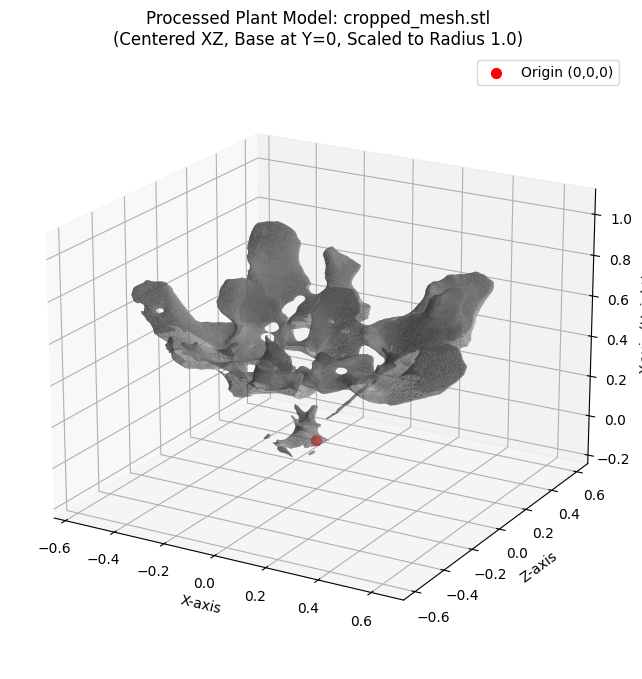


--- Running Experiment: Parallel_Noon_Overhead ---

--- Performing Ray Casting: Parallel_Noon_Overhead ---
Total rays to cast: 100489
DEBUG: Type of mesh passed to intersector: <class 'trimesh.base.Trimesh'>
DEBUG: Is mesh a valid Trimesh object? True
Number of rays intercepted (hit the mesh at least once): 17808
Light Interception Ratio (rays): 0.1772
Number of intercepted rays with multiple hits: 8509
Self-Occlusion Index (multiple hits / total intercepted): 0.4778
Total faces in mesh: 44253
Number of unique faces intercepted (at least once): 18317
Face Interception Ratio (unique faces / total faces): 0.4139
Total initial hits on faces: 17808
Initial Hit Face Ratio (total initial hits / total faces): 0.4024
Total overall hits on faces: 28151
Overall Hit Face Ratio (total overall hits / total faces): 0.6361
Spatial hit data saved to: results/cropped_mesh/spatial_hit_data/Parallel_Noon_Overhead_hits.npy
Visualization saved to: results/cropped_mesh/visualizations/Parallel_Noon_Overhead

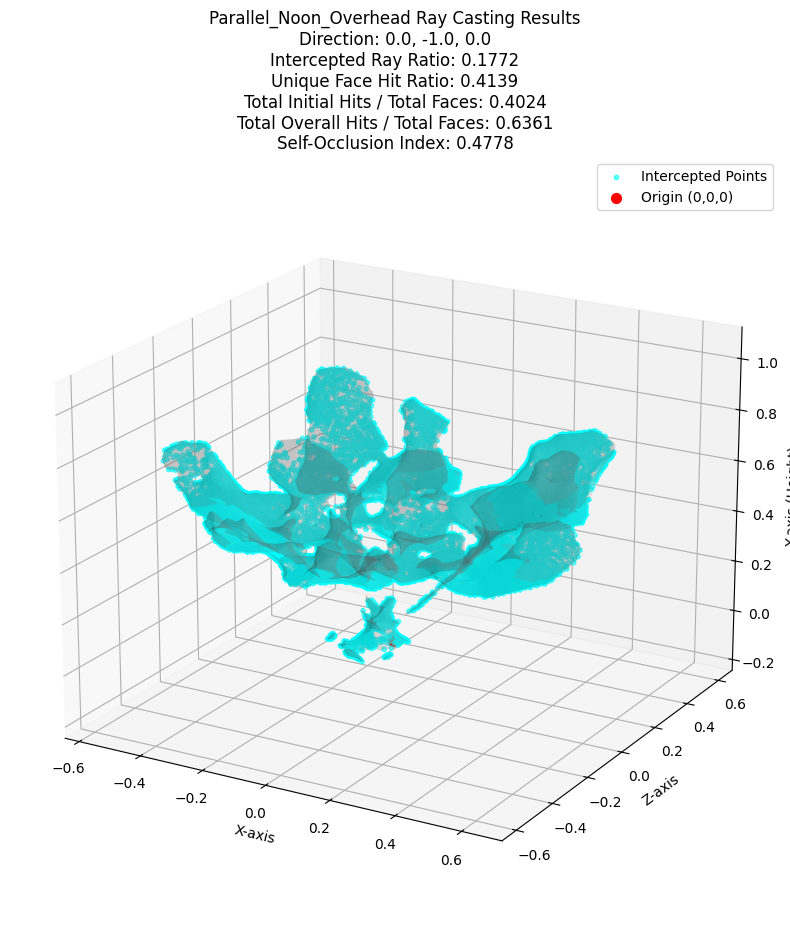


--- Running Experiment: Parallel_Morning_45deg_East ---

--- Performing Ray Casting: Parallel_Morning_45deg_East ---
Total rays to cast: 100489
DEBUG: Type of mesh passed to intersector: <class 'trimesh.base.Trimesh'>
DEBUG: Is mesh a valid Trimesh object? True
Number of rays intercepted (hit the mesh at least once): 6603
Light Interception Ratio (rays): 0.0657
Number of intercepted rays with multiple hits: 3544
Self-Occlusion Index (multiple hits / total intercepted): 0.5367
Total faces in mesh: 44253
Number of unique faces intercepted (at least once): 6276
Face Interception Ratio (unique faces / total faces): 0.1418
Total initial hits on faces: 6603
Initial Hit Face Ratio (total initial hits / total faces): 0.1492
Total overall hits on faces: 11030
Overall Hit Face Ratio (total overall hits / total faces): 0.2492
Spatial hit data saved to: results/cropped_mesh/spatial_hit_data/Parallel_Morning_45deg_East_hits.npy
Visualization saved to: results/cropped_mesh/visualizations/Parallel_M

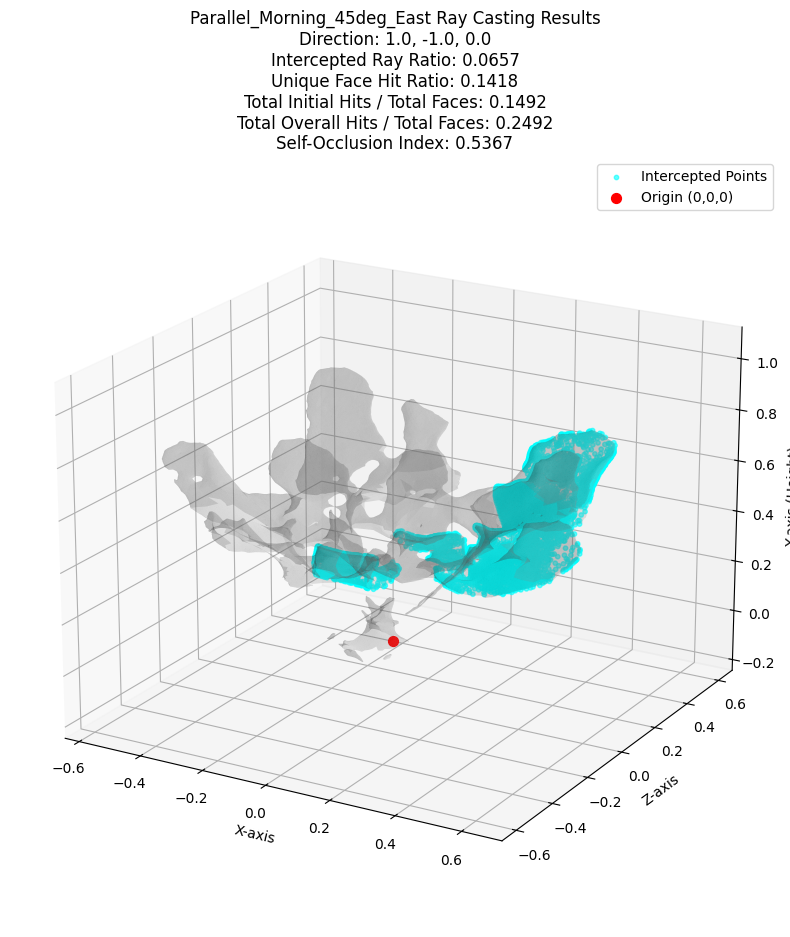


--- Running Experiment: Parallel_Afternoon_45deg_West ---

--- Performing Ray Casting: Parallel_Afternoon_45deg_West ---
Total rays to cast: 100489
DEBUG: Type of mesh passed to intersector: <class 'trimesh.base.Trimesh'>
DEBUG: Is mesh a valid Trimesh object? True
Number of rays intercepted (hit the mesh at least once): 10415
Light Interception Ratio (rays): 0.1036
Number of intercepted rays with multiple hits: 7735
Self-Occlusion Index (multiple hits / total intercepted): 0.7427
Total faces in mesh: 44253
Number of unique faces intercepted (at least once): 8676
Face Interception Ratio (unique faces / total faces): 0.1961
Total initial hits on faces: 10415
Initial Hit Face Ratio (total initial hits / total faces): 0.2354
Total overall hits on faces: 19538
Overall Hit Face Ratio (total overall hits / total faces): 0.4415
Spatial hit data saved to: results/cropped_mesh/spatial_hit_data/Parallel_Afternoon_45deg_West_hits.npy
Visualization saved to: results/cropped_mesh/visualizations/Pa

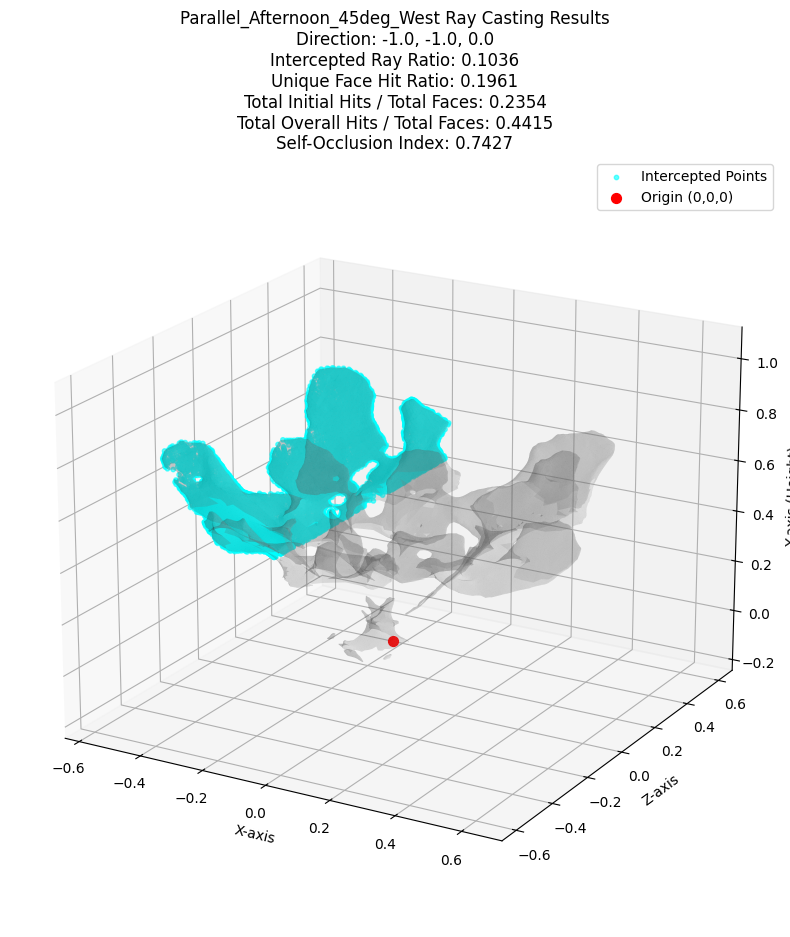


--- Running Experiment: Parallel_Morning_45deg_South ---

--- Performing Ray Casting: Parallel_Morning_45deg_South ---
Total rays to cast: 100489
DEBUG: Type of mesh passed to intersector: <class 'trimesh.base.Trimesh'>
DEBUG: Is mesh a valid Trimesh object? True
Number of rays intercepted (hit the mesh at least once): 10820
Light Interception Ratio (rays): 0.1077
Number of intercepted rays with multiple hits: 8609
Self-Occlusion Index (multiple hits / total intercepted): 0.7957
Total faces in mesh: 44253
Number of unique faces intercepted (at least once): 9969
Face Interception Ratio (unique faces / total faces): 0.2253
Total initial hits on faces: 10820
Initial Hit Face Ratio (total initial hits / total faces): 0.2445
Total overall hits on faces: 21969
Overall Hit Face Ratio (total overall hits / total faces): 0.4964
Spatial hit data saved to: results/cropped_mesh/spatial_hit_data/Parallel_Morning_45deg_South_hits.npy
Visualization saved to: results/cropped_mesh/visualizations/Paral

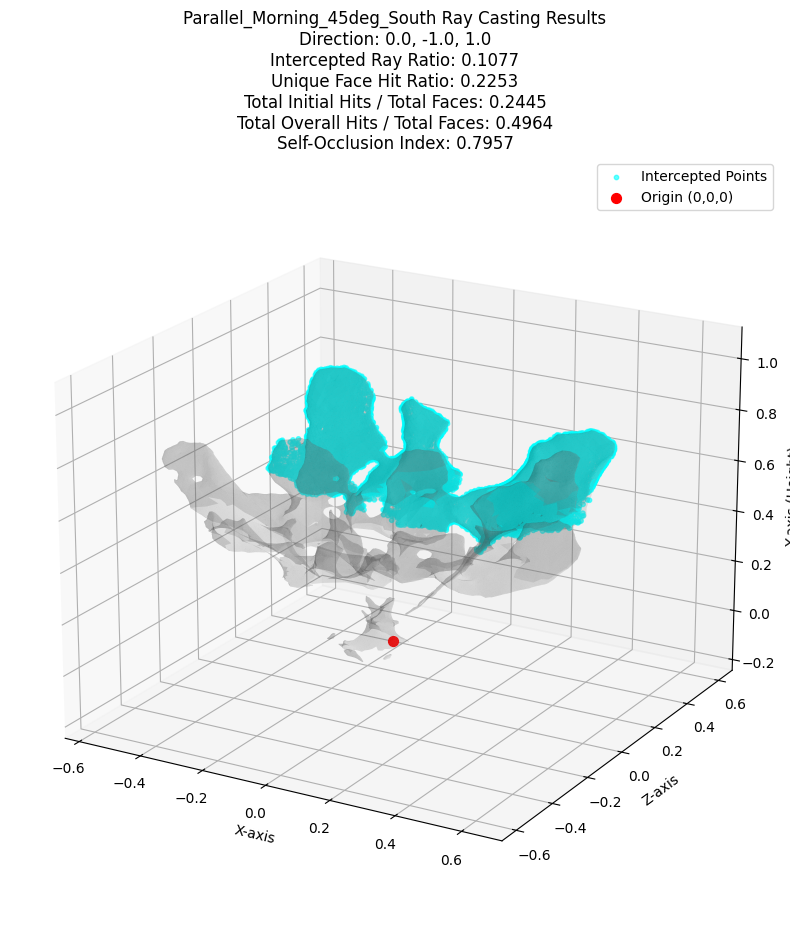


--- Running Experiment: Parallel_Afternoon_45deg_North ---

--- Performing Ray Casting: Parallel_Afternoon_45deg_North ---
Total rays to cast: 100489
DEBUG: Type of mesh passed to intersector: <class 'trimesh.base.Trimesh'>
DEBUG: Is mesh a valid Trimesh object? True
Number of rays intercepted (hit the mesh at least once): 12264
Light Interception Ratio (rays): 0.1220
Number of intercepted rays with multiple hits: 6950
Self-Occlusion Index (multiple hits / total intercepted): 0.5667
Total faces in mesh: 44253
Number of unique faces intercepted (at least once): 10191
Face Interception Ratio (unique faces / total faces): 0.2303
Total initial hits on faces: 12264
Initial Hit Face Ratio (total initial hits / total faces): 0.2771
Total overall hits on faces: 20873
Overall Hit Face Ratio (total overall hits / total faces): 0.4717
Spatial hit data saved to: results/cropped_mesh/spatial_hit_data/Parallel_Afternoon_45deg_North_hits.npy
Visualization saved to: results/cropped_mesh/visualization

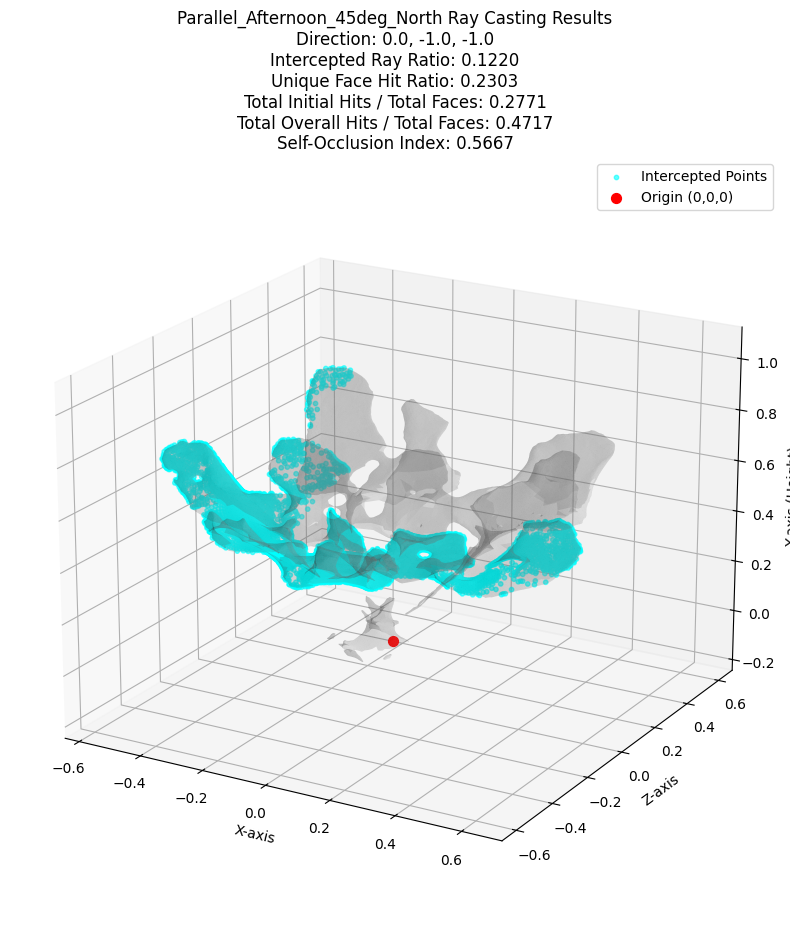


--- Running Experiment: Hemispherical_DiffuseSky ---

--- Performing Ray Casting: Hemispherical_DiffuseSky ---
Total rays to cast: 1000
DEBUG: Type of mesh passed to intersector: <class 'trimesh.base.Trimesh'>
DEBUG: Is mesh a valid Trimesh object? True
Number of rays intercepted (hit the mesh at least once): 535
Light Interception Ratio (rays): 0.5350
Number of intercepted rays with multiple hits: 453
Self-Occlusion Index (multiple hits / total intercepted): 0.8467
Total faces in mesh: 44253
Number of unique faces intercepted (at least once): 1259
Face Interception Ratio (unique faces / total faces): 0.0285
Total initial hits on faces: 535
Initial Hit Face Ratio (total initial hits / total faces): 0.0121
Total overall hits on faces: 1359
Overall Hit Face Ratio (total overall hits / total faces): 0.0307
Spatial hit data saved to: results/cropped_mesh/spatial_hit_data/Hemispherical_DiffuseSky_hits.npy
Visualization saved to: results/cropped_mesh/visualizations/Hemispherical_DiffuseSky_

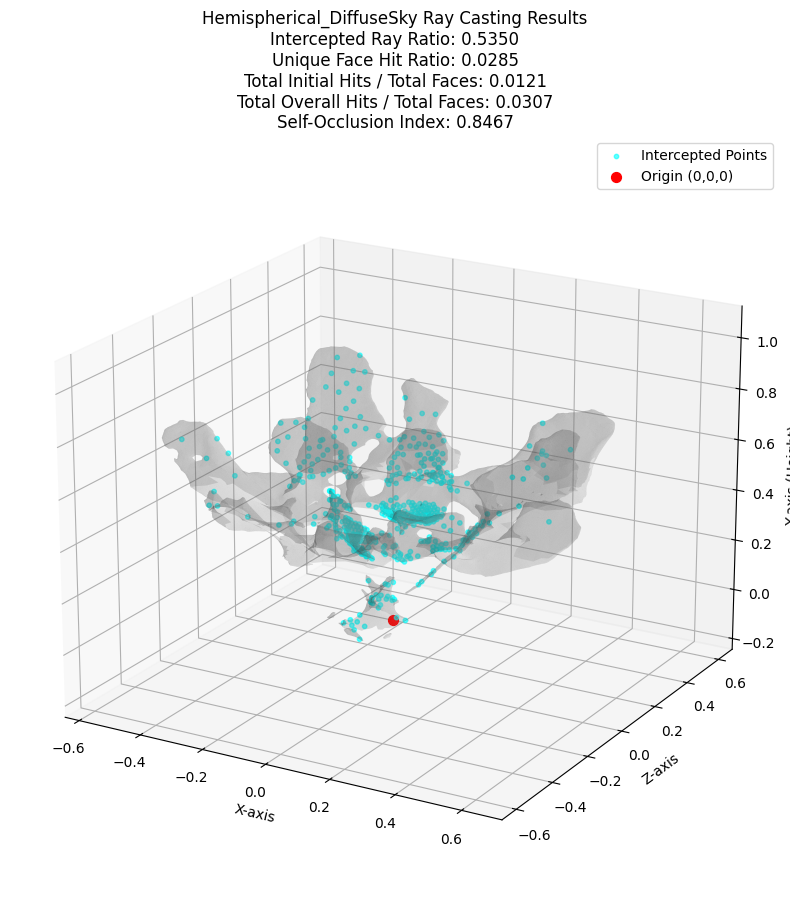


--- ALL EXPERIMENTS SUMMARY RESULTS ---
  plant_model_id  max_xz_radius  max_height  surface_area  bounding_radius_actual                 experiment_name  total_rays  intercepted_rays  light_interception_ratio  num_rays_with_multiple_hits  self_occlusion_index  total_mesh_faces  num_unique_hit_faces  face_interception_ratio  total_initial_hits  initial_hit_face_ratio  total_overall_hits  overall_hit_face_ratio               light_source_type  sun_direction_x  sun_direction_y  sun_direction_z
0   cropped_mesh       0.763782    0.879171      2.094829                     1.0          Parallel_Noon_Overhead      100489             17808                  0.177213                         8509              0.477819             44253                 18317                 0.413915               17808                0.402413               28151                0.636138          Parallel_Noon_Overhead              0.0             -1.0              0.0
1   cropped_mesh       0.763782    0.879171  

In [12]:
import pandas as pd
import numpy as np
import trimesh
import os
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

# --- Step 2: Core STL Loading Function with Pre-processing and STATIC Visualization (FINALIZED with Scaling & Metrics) ---

def load_and_preprocess_stl(stl_path: str, target_bounding_radius: float = 1.0, visualize: bool = True) -> (trimesh.Trimesh, dict):
    """
    Loads an STL file, centers it on the XZ plane, places its lowest point (Y-axis) at the origin,
    scales it to a target bounding radius, and calculates key plant metrics.
    Provides a static 3D visualization using Matplotlib, oriented so Y is vertical on screen.

    Args:
        stl_path (str): The file path to the STL model.
        target_bounding_radius (float): The desired maximum distance from the origin to any point on the plant.
                                        All plants will be scaled so their furthest point is at this radius.
        visualize (bool): If True, displays a static 3D visualization using Matplotlib.

    Returns:
        tuple[trimesh.Trimesh, dict]: A tuple containing:
            - trimesh.Trimesh: The loaded, pre-processed, and scaled Trimesh object (Y-axis remains the height axis).
            - dict: A dictionary of calculated plant metrics:
                    'max_xz_radius', 'max_height', 'surface_area', 'bounding_radius_actual'.
    """
    if not os.path.exists(stl_path):
        raise FileNotFoundError(f"STL file not found at: {stl_path}")

    try:
        mesh = trimesh.load_mesh(stl_path)
        print(f"Successfully loaded mesh from {stl_path}")
        print(f"Mesh has {len(mesh.vertices)} vertices and {len(mesh.faces)} faces.")
        print(f"Mesh bounds (before processing): Min {mesh.bounds[0]}, Max {mesh.bounds[1]}")

    except Exception as e:
        print(f"Error loading STL file: {e}")
        return None, {}

    # 1. Ensure the mesh is a single Trimesh object (not a Scene or list of meshes)
    if isinstance(mesh, trimesh.Scene):
        print("Input is a Trimesh Scene, attempting to concatenate into a single mesh.")
        mesh = mesh.dump(concatenate=True)
    if isinstance(mesh, (list, tuple)):
        print("Input is a list of meshes, attempting to concatenate.")
        mesh = trimesh.util.concatenate(mesh)

    if not isinstance(mesh, trimesh.Trimesh):
        print("Error: Could not convert loaded file into a single Trimesh object.")
        return None, {}

    # --- Pre-processing ---
    # Goal: Center XZ at origin, lowest Y at origin.
    # This assumes Y is the 'up' axis for internal data representation.

    # 1. Translate centroid to origin for X and Z components
    initial_centroid = mesh.centroid
    translation_xz = -initial_centroid[[0, 2]]
    mesh.apply_translation(np.array([translation_xz[0], 0, translation_xz[1]]))
    print(f"Model centered on XZ plane. Initial centroid: {initial_centroid}, New centroid (approx): {mesh.centroid}")

    # 2. Translate lowest Y point to origin
    min_y = mesh.bounds[0][1] # Get the minimum Y coordinate of the mesh
    translation_y = -min_y
    mesh.apply_translation(np.array([0, translation_y, 0])) # Only translate in Y
    print(f"Model base translated to origin along Y-axis (min Y = 0).")

    # Diagnostic print to check actual Y-min after translation
    final_min_y = mesh.bounds[0][1]
    print(f"Mesh bounds (after base translation): Min {mesh.bounds[0]}, Max {mesh.bounds[1]}")
    print(f"CONFIRMATION: Final Y-min of mesh: {final_min_y}")

    # 3. Scaling to Target Bounding Radius
    # Calculate the current maximum distance from the origin to any vertex
    current_bounding_radius = np.linalg.norm(mesh.vertices, axis=1).max()
    if current_bounding_radius == 0: # Avoid division by zero for degenerate meshes
        print("Warning: Mesh has zero bounding radius, cannot scale.")
        scaling_factor = 1.0
    else:
        scaling_factor = target_bounding_radius / current_bounding_radius
    mesh.apply_scale(scaling_factor)
    
    # Update bounding radius after scaling
    actual_bounding_radius = np.linalg.norm(mesh.vertices, axis=1).max()
    print(f"Model scaled. Original bounding radius: {current_bounding_radius:.4f}, Target: {target_bounding_radius:.4f}, Actual: {actual_bounding_radius:.4f}")
    print(f"Mesh bounds (after scaling): Min {mesh.bounds[0]}, Max {mesh.bounds[1]}")


    # 4. Calculate New Plant Metrics (after all transformations)
    max_xz_radius = np.linalg.norm(mesh.vertices[:, [0, 2]], axis=1).max()
    max_height = mesh.bounds[1][1] # Since min_y is 0, this is the height
    surface_area = mesh.area

    plant_metrics = {
        'max_xz_radius': max_xz_radius,
        'max_height': max_height,
        'surface_area': surface_area,
        'bounding_radius_actual': actual_bounding_radius
    }
    print(f"Calculated Plant Metrics: {plant_metrics}")


    # 5. Visualization (Static for Jupyter via Matplotlib)
    if visualize:
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')

        # --- TEMPORARY AXIS SWAP FOR VISUALIZATION ONLY ---
        viz_vertices = mesh.vertices.copy()
        viz_vertices[:, [1, 2]] = viz_vertices[:, [2, 1]] # Swap Y and Z columns

        ax.plot_trisurf(viz_vertices[:, 0], viz_vertices[:, 1], viz_vertices[:, 2],
                        triangles=mesh.faces, color='#a0a0a0', alpha=0.8, edgecolor='none')

        ax.set_xlabel('X-axis')
        ax.set_ylabel('Z-axis')
        ax.set_zlabel('Y-axis (Height)')
        ax.set_title(f'Processed Plant Model: {os.path.basename(stl_path)}\n(Centered XZ, Base at Y=0, Scaled to Radius {target_bounding_radius})')

        # Set equal aspect ratio
        viz_bounds_min = np.min(viz_vertices, axis=0)
        viz_bounds_max = np.max(viz_vertices, axis=0)
        max_dim = np.max(viz_bounds_max - viz_bounds_min)
        mid_x_viz = (viz_bounds_min[0] + viz_bounds_max[0]) / 2
        mid_y_viz = (viz_bounds_min[1] + viz_bounds_max[1]) / 2
        mid_z_viz = (viz_bounds_min[2] + viz_bounds_max[2]) / 2

        ax.set_xlim(mid_x_viz - max_dim / 2, mid_x_viz + max_dim / 2)
        ax.set_ylim(mid_y_viz - max_dim / 2, mid_y_viz + max_dim / 2)
        ax.set_zlim(mid_z_viz - max_dim / 2, mid_z_viz + max_dim / 2)

        ax.scatter(0, 0, 0, color='red', s=50, label='Origin (0,0,0)')
        ax.legend()
        ax.view_init(elev=20, azim=-60)
        plt.show()

    else:
        print("Static visualization skipped.")

    return mesh, plant_metrics


# --- Step 3: Refactor Ray Generation (no changes to these functions) ---

def fibonacci_sphere(num_points: int) -> np.ndarray:
    """
    Generates approximately uniformly distributed points on the surface of a unit sphere.
    """
    points = []
    phi = np.pi * (3. - np.sqrt(5.))
    for i in range(num_points):
        y = 1 - (i / float(num_points - 1)) * 2
        radius = np.sqrt(1 - y * y)
        theta = phi * i
        x = np.cos(theta) * radius
        z = np.sin(theta) * radius
        points.append([x, y, z])
    return np.array(points)


def generate_parallel_rays(direction: np.ndarray, num_rays: int,
                           mesh_bounds: np.ndarray, offset_multiplier: float = 1.5) -> (np.ndarray, np.ndarray):
    """
    Generates parallel rays originating from a plane above and surrounding the mesh.
    """
    direction = direction / np.linalg.norm(direction)

    x_min, y_min, z_min = mesh_bounds[0]
    x_max, y_max, z_max = mesh_bounds[1]
    extents = mesh_bounds[1] - mesh_bounds[0]
    max_overall_dim = np.max(extents)

    x_span = (x_max - x_min) * offset_multiplier
    z_span = (z_max - z_min) * offset_multiplier
    center_x = (x_min + x_max) / 2
    center_z = (z_min + z_max) / 2

    num_side = int(np.ceil(np.sqrt(num_rays)))
    xs = np.linspace(center_x - x_span/2, center_x + x_span/2, num_side)
    zs = np.linspace(center_z - z_span/2, center_z + z_span/2, num_side)
    grid_xx, grid_zz = np.meshgrid(xs, zs)

    # Calculate origin_y_coord based on sun direction
    # If sun comes from above (negative Y direction), rays start above mesh_max_y
    # If sun comes from below (positive Y direction), rays start below mesh_min_y
    # This assumes Y is the height axis
    if direction[1] < 0: # Sun coming from above
        origin_y_coord = y_max + max_overall_dim * 0.5 # Start above the highest point
    else: # Sun coming from below or horizontally
        origin_y_coord = y_min - max_overall_dim * 0.5 # Start below the lowest point

    ray_origins = np.vstack([grid_xx.ravel(), np.full(grid_xx.size, origin_y_coord), grid_zz.ravel()]).T
    ray_directions = np.tile(direction, (ray_origins.shape[0], 1))

    return ray_origins, ray_directions


def generate_hemispherical_rays(num_rays: int, mesh_bounds: np.ndarray, radius_multiplier: float = 1.5) -> (np.ndarray, np.ndarray):
    """
    Generates rays originating from points on a hemisphere above the mesh,
    all directed towards the center of the mesh.
    """
    mesh_center = (mesh_bounds[0] + mesh_bounds[1]) / 2
    extents = mesh_bounds[1] - mesh_bounds[0]
    max_mesh_dim = np.max(extents)
    hemisphere_radius = max_mesh_dim * radius_multiplier

    temp_sphere_points = fibonacci_sphere(int(num_rays * 2)) # Generate more points than needed to pick from
    # Filter for upper hemisphere points (Y >= 0, assuming Y is vertical axis for sphere points)
    hemisphere_points_raw = temp_sphere_points[temp_sphere_points[:, 1] >= 0]

    # Sample exactly num_rays points from the hemisphere
    if hemisphere_points_raw.shape[0] < num_rays:
        print(f"Warning: Not enough unique hemisphere points ({hemisphere_points_raw.shape[0]}) generated. Resampling with replacement to reach {num_rays}.")
        indices = np.random.choice(hemisphere_points_raw.shape[0], num_rays, replace=True)
        hemisphere_points = hemisphere_points_raw[indices]
    elif hemisphere_points_raw.shape[0] > num_rays:
        indices = np.random.choice(hemisphere_points_raw.shape[0], num_rays, replace=False)
        hemisphere_points = hemisphere_points_raw[indices]
    else:
        hemisphere_points = hemisphere_points_raw
        
    # Scale hemisphere points to the desired radius and offset them relative to the mesh
    ray_origins = hemisphere_points * hemisphere_radius
    
    # Offset the hemisphere's center for its origins slightly above the plant's max Y to fully encompass it
    # This ensures rays start above the plant and point down towards its center.
    y_offset_for_hemisphere_center = mesh_bounds[1][1] + max_mesh_dim * 0.1 # Plant's max Y + a small buffer
    
    ray_origins[:, 0] += mesh_center[0]
    ray_origins[:, 1] += y_offset_for_hemisphere_center
    ray_origins[:, 2] += mesh_center[2]

    # Directions point from origin points towards the mesh center
    ray_directions = mesh_center - ray_origins
    ray_directions = ray_directions / np.linalg.norm(ray_directions, axis=1)[:, np.newaxis]

    return ray_origins, ray_directions


# --- Step 4: Revamp Ray Casting for STL Occlusion (WITH SELF-OCCLUSION METRIC - no changes, already done) ---

def perform_ray_casting(mesh: trimesh.Trimesh, ray_origins: np.ndarray, ray_directions: np.ndarray,
                        name: str = "Experiment") -> dict:
    """
    Performs ray casting on a given mesh and calculates light interception and self-occlusion metrics.
    """
    if not isinstance(mesh, trimesh.Trimesh):
        raise TypeError("Input 'mesh' must be a trimesh.Trimesh object.")
    if ray_origins.shape[1] != 3 or ray_directions.shape[1] != 3:
        raise ValueError("Ray origins and directions must be N x 3 arrays.")
    if ray_origins.shape[0] != ray_directions.shape[0]:
        raise ValueError("Number of ray origins and directions must match.")

    print(f"\n--- Performing Ray Casting: {name} ---")
    print(f"Total rays to cast: {len(ray_origins)}")

    # DEBUG: Add these lines here *before* the intersector creation
    print(f"DEBUG: Type of mesh passed to intersector: {type(mesh)}")
    print(f"DEBUG: Is mesh a valid Trimesh object? {isinstance(mesh, trimesh.Trimesh)}")
    # End DEBUG

    from trimesh.ray.ray_triangle import RayMeshIntersector 
    
    intersector = RayMeshIntersector(mesh) 

    locations, ray_indices, face_indices = intersector.intersects_location(
        ray_origins, ray_directions, return_ray_ids=True, return_face_ids=True
    )
    
    unique_hit_ray_indices, first_hit_indices = np.unique(ray_indices, return_index=True)
    num_intercepted_rays = len(unique_hit_ray_indices)
    light_interception_ratio = num_intercepted_rays / len(ray_origins) if len(ray_origins) > 0 else 0

    print(f"Number of rays intercepted (hit the mesh at least once): {num_intercepted_rays}")
    print(f"Light Interception Ratio (rays): {light_interception_ratio:.4f}")

    unique_rays_that_hit_all_instances, counts_per_ray = np.unique(ray_indices, return_counts=True)
    rays_with_multiple_hits_mask = (counts_per_ray > 1)
    num_rays_with_multiple_hits = np.sum(rays_with_multiple_hits_mask)

    self_occlusion_index = num_rays_with_multiple_hits / num_intercepted_rays if num_intercepted_rays > 0 else 0

    print(f"Number of intercepted rays with multiple hits: {num_rays_with_multiple_hits}")
    print(f"Self-Occlusion Index (multiple hits / total intercepted): {self_occlusion_index:.4f}")

    # --- EXPANDED FACE INTERCEPTION METRICS ---
    total_mesh_faces = len(mesh.faces) # Total number of faces in the mesh

    # 1. Unique Faces Hit at Least Once (already there, just clarifying)
    unique_hit_faces = np.unique(face_indices)
    num_unique_hit_faces = len(unique_hit_faces)
    face_interception_ratio = num_unique_hit_faces / total_mesh_faces if total_mesh_faces > 0 else 0
    
    # 2. Total Initial Hits (count of all first hits, even if on the same face)
    # This is equivalent to the number of intercepted rays (each ray has one initial hit)
    total_initial_hits = num_intercepted_rays # Renamed for clarity on face metrics context
    initial_hit_face_ratio = total_initial_hits / total_mesh_faces if total_mesh_faces > 0 else 0

    # 3. Total Overall Hits (count of ALL hits, including multiple hits per ray/face)
    total_overall_hits = len(face_indices) # This is the raw count of all recorded intersections
    overall_hit_face_ratio = total_overall_hits / total_mesh_faces if total_mesh_faces > 0 else 0

    print(f"Total faces in mesh: {total_mesh_faces}")
    print(f"Number of unique faces intercepted (at least once): {num_unique_hit_faces}")
    print(f"Face Interception Ratio (unique faces / total faces): {face_interception_ratio:.4f}")
    print(f"Total initial hits on faces: {total_initial_hits}")
    print(f"Initial Hit Face Ratio (total initial hits / total faces): {initial_hit_face_ratio:.4f}")
    print(f"Total overall hits on faces: {total_overall_hits}")
    print(f"Overall Hit Face Ratio (total overall hits / total faces): {overall_hit_face_ratio:.4f}")
    # --- END EXPANDED FACE INTERCEPTION METRICS ---

    first_hit_locations = locations[first_hit_indices]
    first_hit_face_indices = face_indices[first_hit_indices]

    results = {
        'experiment_name': name,
        'total_rays': len(ray_origins),
        'intercepted_rays': num_intercepted_rays,
        'light_interception_ratio': light_interception_ratio, # Based on rays
        'num_rays_with_multiple_hits': num_rays_with_multiple_hits,
        'self_occlusion_index': self_occlusion_index,
        
        # New/expanded face metrics
        'total_mesh_faces': total_mesh_faces,
        'num_unique_hit_faces': num_unique_hit_faces,
        'face_interception_ratio': face_interception_ratio,
        'total_initial_hits': total_initial_hits,
        'initial_hit_face_ratio': initial_hit_face_ratio,
        'total_overall_hits': total_overall_hits,
        'overall_hit_face_ratio': overall_hit_face_ratio,

        'hit_locations': first_hit_locations,
        'hit_ray_indices': unique_hit_ray_indices,
        'hit_face_indices': first_hit_face_indices
    }
    return results

def visualize_ray_casting_results(mesh: trimesh.Trimesh, ray_casting_results: dict,
                                  sun_direction: np.ndarray = None, ray_type: str = "Parallel",
                                  save_path: str = None) -> None:
    """
    Visualizes the mesh and the points on its surface that were hit by rays (first hit only).
    Can save the plot as a PNG file.

    Args:
        mesh (trimesh.Trimesh): The original plant mesh (Y-up orientation).
        ray_casting_results (dict): Dictionary returned by perform_ray_casting.
        sun_direction (np.ndarray, optional): Direction of parallel rays if applicable, for title.
        ray_type (str): Type of rays ('Parallel' or 'Hemispherical') for title.
        save_path (str, optional): Full path (including filename and .png extension) to save the plot.
                                    If None, the plot is displayed but not saved.
    """
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    viz_vertices = mesh.vertices.copy()
    viz_vertices[:, [1, 2]] = viz_vertices[:, [2, 1]]

    ax.plot_trisurf(viz_vertices[:, 0], viz_vertices[:, 1], viz_vertices[:, 2],
                    triangles=mesh.faces, color='#a0a0a0', alpha=0.2, edgecolor='none')

    hit_locations = ray_casting_results['hit_locations']
    if hit_locations.shape[0] > 0:
        viz_hit_locations = hit_locations.copy()
        viz_hit_locations[:, [1, 2]] = viz_hit_locations[:, [2, 1]]
        ax.scatter(viz_hit_locations[:, 0], viz_hit_locations[:, 1], viz_hit_locations[:, 2],
                   color='cyan', s=10, alpha=0.6, label='Intercepted Points')
    else:
        print("No rays intercepted the mesh for visualization.")

    ax.set_xlabel('X-axis')
    ax.set_ylabel('Z-axis')
    ax.set_zlabel('Y-axis (Height)')
    
    title_parts = [
        f'{ray_casting_results["experiment_name"]} Ray Casting Results',
        f'Intercepted Ray Ratio: {ray_casting_results["light_interception_ratio"]:.4f}',
        f'Unique Face Hit Ratio: {ray_casting_results["face_interception_ratio"]:.4f}',
        f'Total Initial Hits / Total Faces: {ray_casting_results["initial_hit_face_ratio"]:.4f}',
        f'Total Overall Hits / Total Faces: {ray_casting_results["overall_hit_face_ratio"]:.4f}',
        f'Self-Occlusion Index: {ray_casting_results["self_occlusion_index"]:.4f}'
    ]
    if sun_direction is not None:
        title_parts.insert(1, f'Direction: {sun_direction[0]:.1f}, {sun_direction[1]:.1f}, {sun_direction[2]:.1f}')
    
    ax.set_title('\n'.join(title_parts))

    all_viz_points = viz_vertices
    if hit_locations.shape[0] > 0:
        all_viz_points = np.vstack([viz_vertices, viz_hit_locations])

    min_combined_bounds = np.min(all_viz_points, axis=0)
    max_combined_bounds = np.max(all_viz_points, axis=0)
    max_combined_dim = np.max(max_combined_bounds - min_combined_bounds)
    
    mid_x_combined = (min_combined_bounds[0] + max_combined_bounds[0]) / 2
    mid_y_combined = (min_combined_bounds[1] + max_combined_bounds[1]) / 2
    mid_z_combined = (min_combined_bounds[2] + max_combined_bounds[2]) / 2

    ax.set_xlim(mid_x_combined - max_combined_dim / 2, mid_x_combined + max_combined_dim / 2)
    ax.set_ylim(mid_y_combined - max_combined_dim / 2, mid_y_combined + max_combined_dim / 2)
    ax.set_zlim(mid_z_combined - max_combined_dim / 2, mid_z_combined + max_combined_dim / 2)
    
    ax.view_init(elev=20, azim=-60)
    ax.scatter(0, 0, 0, color='red', s=50, label='Origin (0,0,0)')
    ax.legend()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Visualization saved to: {save_path}")
    plt.show()
    plt.close(fig) # Close the figure to free up memory

# --- EXECUTABLE BLOCK: Main Script for Running Multiple Experiments ---

# Define your list of plant STL files here.
plant_stl_files = ['cropped_mesh.stl'] # Currently using only one

# Define ray casting parameters
num_rays_parallel = 100000       # High number for good statistical sampling with parallel rays
num_rays_hemispherical = 1000   # Reduced number for hemispherical rays (due to performance)
target_bounding_radius = 1.0     # All plants will be scaled so their max extent from origin is 1 unit

# Define parallel light directions (sun angles)
# Format: [X, Y, Z] direction vector (Y is height, so negative Y is downwards for sun coming from above)
sun_angles = {
    "Noon_Overhead": np.array([0.0, -1.0, 0.0]), # Sun directly overhead
    
    # 45-degree angles (approximately) from the cardinal directions, coming from above
    # The direction vector points from the sun towards the plant
    "Morning_45deg_East": np.array([1.0, -1.0, 0.0]),    # Sun from positive X (East)
    "Afternoon_45deg_West": np.array([-1.0, -1.0, 0.0]), # Sun from negative X (West)
    "Morning_45deg_South": np.array([0.0, -1.0, 1.0]),   # Sun from positive Z (South)
    "Afternoon_45deg_North": np.array([0.0, -1.0, -1.0]) # Sun from negative Z (North)
}

all_plant_experiment_results = [] # Master list to store all results for all plants and experiments
base_output_dir = "results"
os.makedirs(base_output_dir, exist_ok=True) # Create top-level results directory

# --- Main Loop: Iterate through each plant model ---
for stl_file_path in plant_stl_files:
    plant_id = os.path.splitext(os.path.basename(stl_file_path))[0] # E.g., 'cropped_mesh'

    # Create plant-specific subdirectories for spatial data and visualizations
    plant_output_dir = os.path.join(base_output_dir, plant_id)
    spatial_data_dir = os.path.join(plant_output_dir, "spatial_hit_data")
    visualization_dir = os.path.join(plant_output_dir, "visualizations")
    
    os.makedirs(spatial_data_dir, exist_ok=True)
    os.makedirs(visualization_dir, exist_ok=True)

    print(f"\n==================================================")
    print(f"Processing Plant Model: {plant_id}")
    print(f"Outputting data to: {plant_output_dir}")
    print(f"==================================================")

    # Load, preprocess, and scale the plant mesh, and get its intrinsic metrics
    loaded_plant_mesh, plant_metrics = load_and_preprocess_stl(
        stl_file_path,
        target_bounding_radius=target_bounding_radius,
        visualize=True # Visualize each processed plant initially
    )

    if loaded_plant_mesh is None:
        print(f"Skipping ray casting for {plant_id} due to loading error.")
        continue # Move to next plant if loading failed

    mesh_bounds = loaded_plant_mesh.bounds

    # Add plant intrinsic metrics to the results for this plant
    base_result_row = {
        'plant_model_id': plant_id,
        'max_xz_radius': plant_metrics['max_xz_radius'],
        'max_height': plant_metrics['max_height'],
        'surface_area': plant_metrics['surface_area'],
        'bounding_radius_actual': plant_metrics['bounding_radius_actual']
    }

    # --- Experiment with Parallel Rays (different sun angles) ---
    for angle_name, direction_vector in sun_angles.items():
        experiment_name = f"Parallel_{angle_name}"
        print(f"\n--- Running Experiment: {experiment_name} ---")

        parallel_ray_origins, parallel_ray_directions = generate_parallel_rays(
            direction_vector, num_rays_parallel, mesh_bounds # Using num_rays_parallel here
        )
        
        ray_casting_results = perform_ray_casting(
            loaded_plant_mesh, parallel_ray_origins, parallel_ray_directions,
            name=experiment_name
        )
        
        # Combine base plant metrics with ray casting results for this experiment
        full_result_row = {**base_result_row, **{k: v for k, v in ray_casting_results.items() if k not in ['hit_locations', 'hit_ray_indices', 'hit_face_indices']}}
        full_result_row['light_source_type'] = experiment_name # Uses the full experiment name (e.g., "Parallel_Noon_Overhead")
        full_result_row['sun_direction_x'] = direction_vector[0]
        full_result_row['sun_direction_y'] = direction_vector[1]
        full_result_row['sun_direction_z'] = direction_vector[2]
        all_plant_experiment_results.append(full_result_row)

        # Save spatial hit data separately
        spatial_data_filename = os.path.join(spatial_data_dir, f"{experiment_name}_hits.npy")
        np.save(spatial_data_filename, ray_casting_results['hit_locations'])
        print(f"Spatial hit data saved to: {spatial_data_filename}")

        # Save and display visualization for this experiment
        viz_filename = os.path.join(visualization_dir, f"{experiment_name}_viz.png")
        visualize_ray_casting_results(loaded_plant_mesh, ray_casting_results, sun_direction=direction_vector, ray_type="Parallel", save_path=viz_filename)


    # --- Experiment with Hemispherical Rays (Diffuse Sky Light) ---
    experiment_name = "Hemispherical_DiffuseSky"
    print(f"\n--- Running Experiment: {experiment_name} ---")

    hemispherical_ray_origins, hemispherical_ray_directions = generate_hemispherical_rays(
        num_rays_hemispherical, mesh_bounds, radius_multiplier=2.0 # Using num_rays_hemispherical here
    )
    
    ray_casting_results = perform_ray_casting(
        loaded_plant_mesh, hemispherical_ray_origins, hemispherical_ray_directions,
        name=experiment_name
    )
    
    # Combine base plant metrics with ray casting results for this experiment
    full_result_row = {**base_result_row, **{k: v for k, v in ray_casting_results.items() if k not in ['hit_locations', 'hit_ray_indices', 'hit_face_indices']}}
    full_result_row['light_source_type'] = 'Hemispherical_DiffuseSky' # Keep this as a single name for hemispherical
    full_result_row['sun_direction_x'] = np.nan # Not applicable for hemispherical
    full_result_row['sun_direction_y'] = np.nan
    full_result_row['sun_direction_z'] = np.nan
    all_plant_experiment_results.append(full_result_row)

    # Save spatial hit data separately
    spatial_data_filename = os.path.join(spatial_data_dir, f"{experiment_name}_hits.npy")
    np.save(spatial_data_filename, ray_casting_results['hit_locations'])
    print(f"Spatial hit data saved to: {spatial_data_filename}")

    # Save and display visualization for this experiment
    viz_filename = os.path.join(visualization_dir, f"{experiment_name}_viz.png")
    visualize_ray_casting_results(loaded_plant_mesh, ray_casting_results, ray_type="Hemispherical", save_path=viz_filename)


# --- Final Consolidation and Analysis ---
if all_plant_experiment_results:
    final_results_df = pd.DataFrame(all_plant_experiment_results)
    print("\n==================================================")
    print("--- ALL EXPERIMENTS SUMMARY RESULTS ---")
    print("==================================================")
    print(final_results_df.to_string())

    # Save the final summary DataFrame to a CSV file in the top-level results directory
    output_summary_csv = os.path.join(base_output_dir, "ray_casting_summary_results.csv")
    final_results_df.to_csv(output_summary_csv, index=False)
    print(f"\nSummary results for all plants and experiments saved to: {output_summary_csv}")
else:
    print("\nNo experiment results to summarize.")